Code which plots the equations in the main text and SI of McMahon et al. The snapshot effect: can slower decay translate into worse average preservation of fossils? All plotting is done in Python and is simple plotting of the reletively simple equations included in the manuscript. 

Code is just plotting of the equations there are no complex strcutures or dependecies beyond matplolib, numpy, scipy etc so is presented as a jupyter notebook which directly write the key equations with a few safety checks to prevent dividing by zero etc.

In [1]:
import numpy as np
from scipy.stats import hmean

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
# Enable LaTeX for all text
mpl.rcParams['text.usetex'] = True

# Optional: enforce Computer Modern font consistency
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Computer Modern']

# High-quality output settings
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['savefig.bbox'] = 'tight'

In [2]:

#Main expression from the constant linear decay rate case

def equilibrium_constant_decay(tau, delta):
    delta = np.asarray(delta)
    tau = np.asarray(tau)
    return (2 * tau * delta + 1) / (2 * tau * delta + 2)









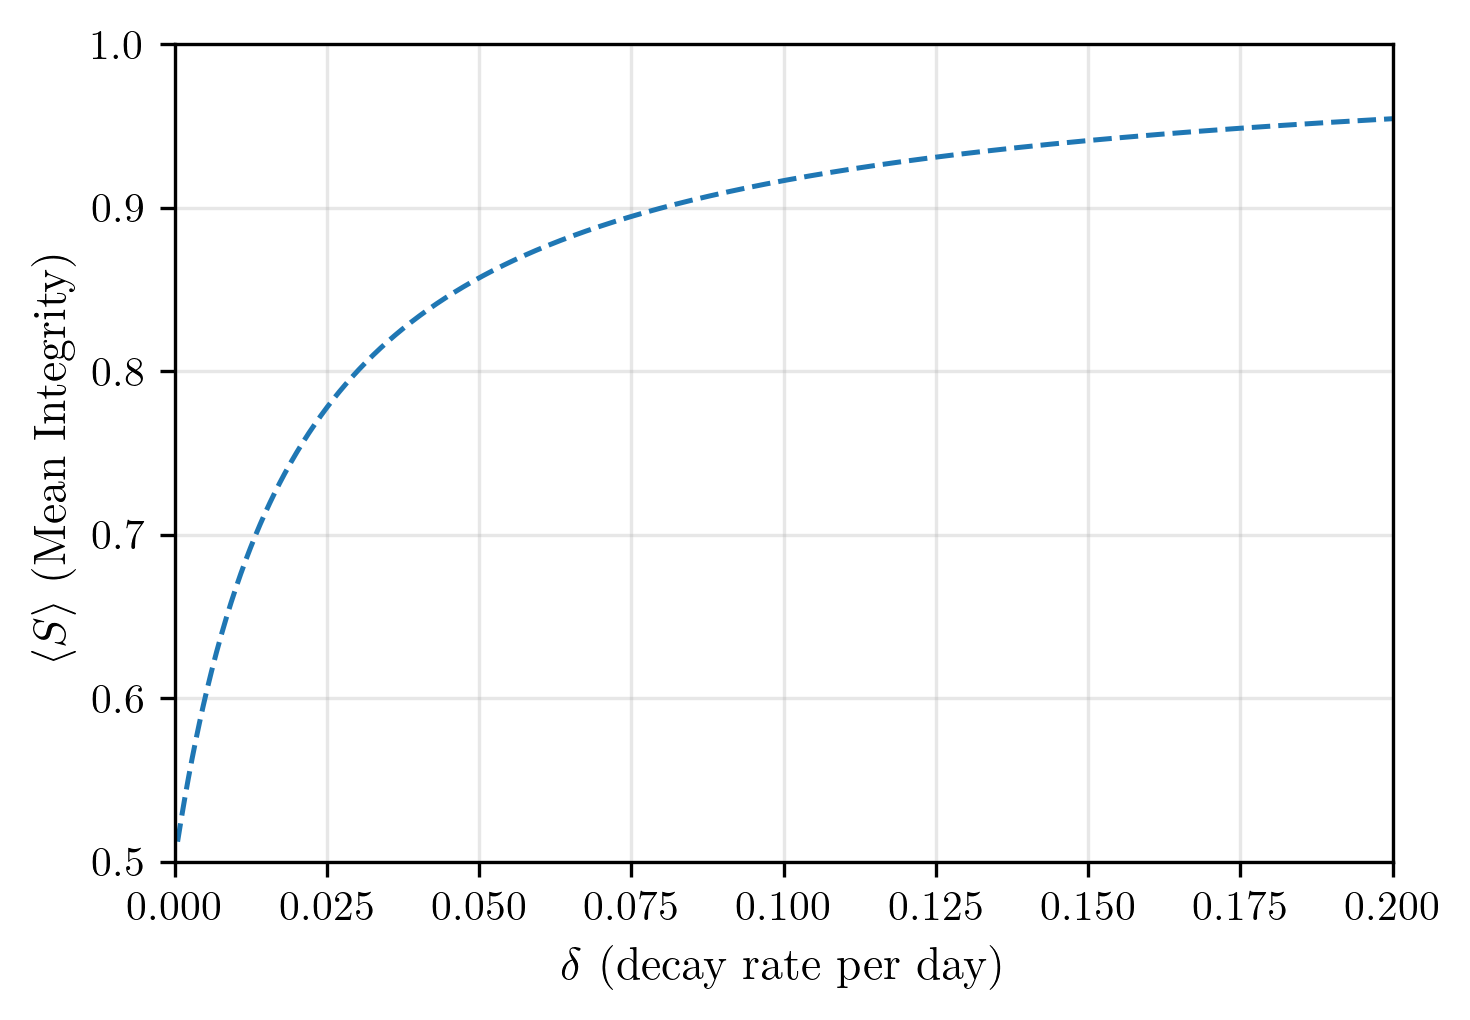

In [3]:




tau = 50

decay_rate = np.linspace(0.0005, 0.2, num =1000)


tau = 50
decay_rate = np.linspace(0.0005, 0.2, num=1000)
S_1 = equilibrium_constant_decay(tau, decay_rate) 




fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(decay_rate, S_1,  linewidth=1.2, ls="--")

ax.set_xlabel(r'$\delta$ (decay rate per day) ', fontsize=11)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=11)
#ax.set_title(r'$\tau = 50$', fontsize=11)

ax.set_xlim([0, 0.2])
ax.set_ylim([0.5, 1.0])  # Function asymptotes to 1
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('equilibrium_constant_decay_rate_preservation.png', dpi=300)
plt.show()








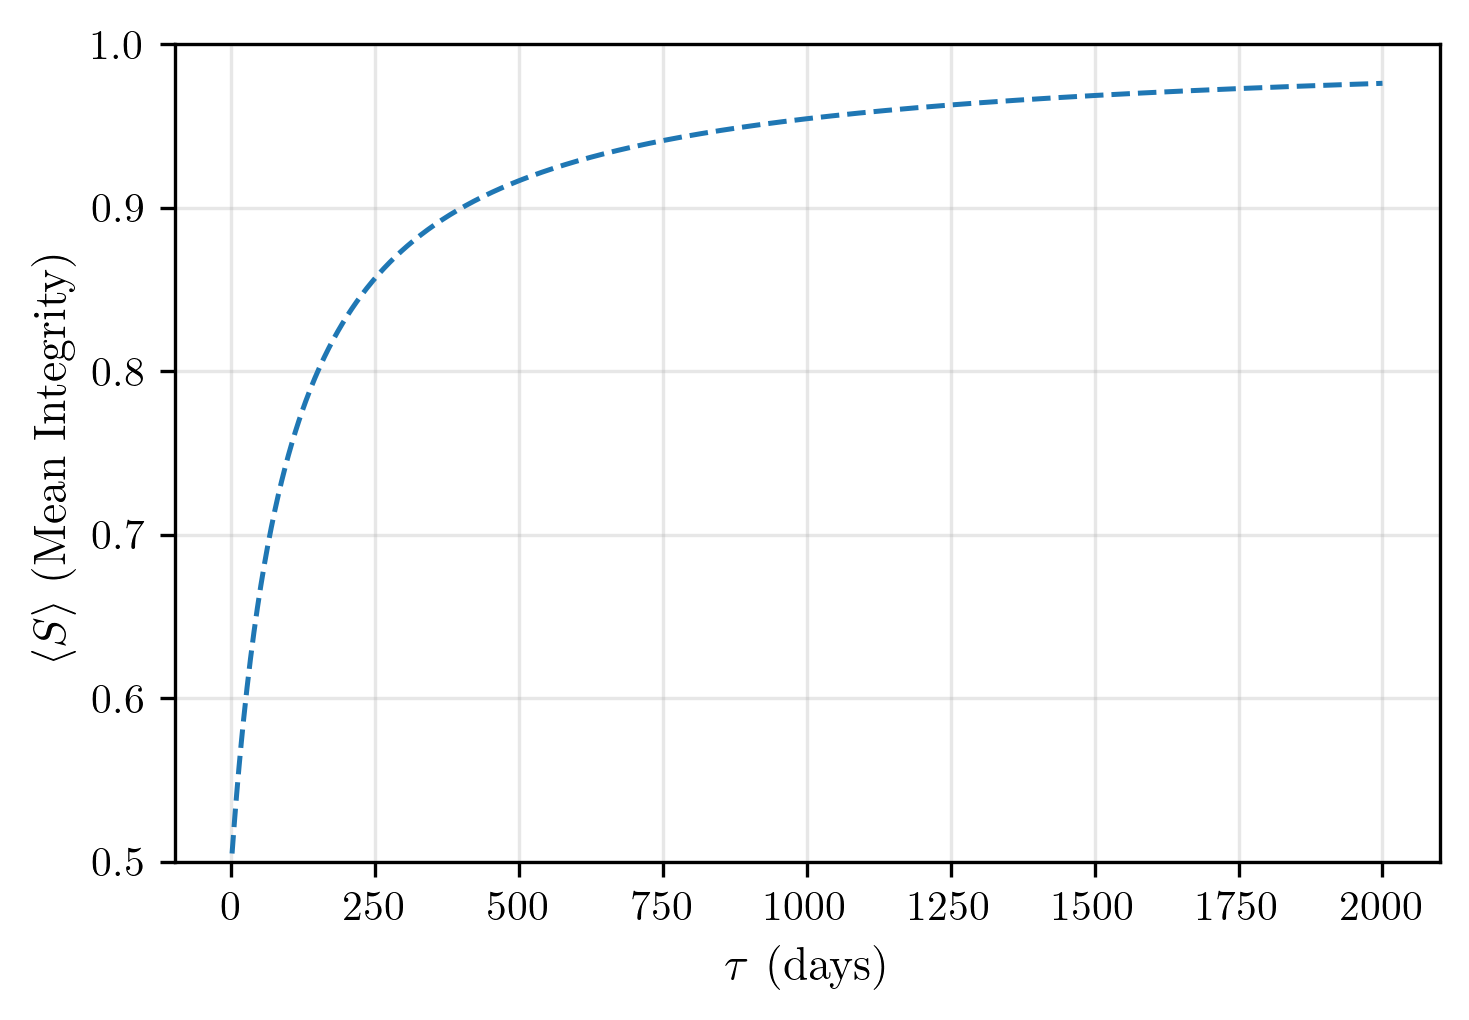

In [4]:


tau  = np.linspace(1, 2000, num =1000)



decay_rate = 0.01
S_2 = equilibrium_constant_decay(tau, decay_rate) 




fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(tau , S_2,  linewidth=1.2, ls="--")

ax.set_xlabel(r'$\tau$ (days)', fontsize=11)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=11)
#ax.set_title(r'$\tau = 50$', fontsize=11)


ax.set_ylim([0.5, 1.0])  # Function asymptotes to 1
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('equilibrium_constant_lifespan_preservation.png', dpi=300)
plt.show()



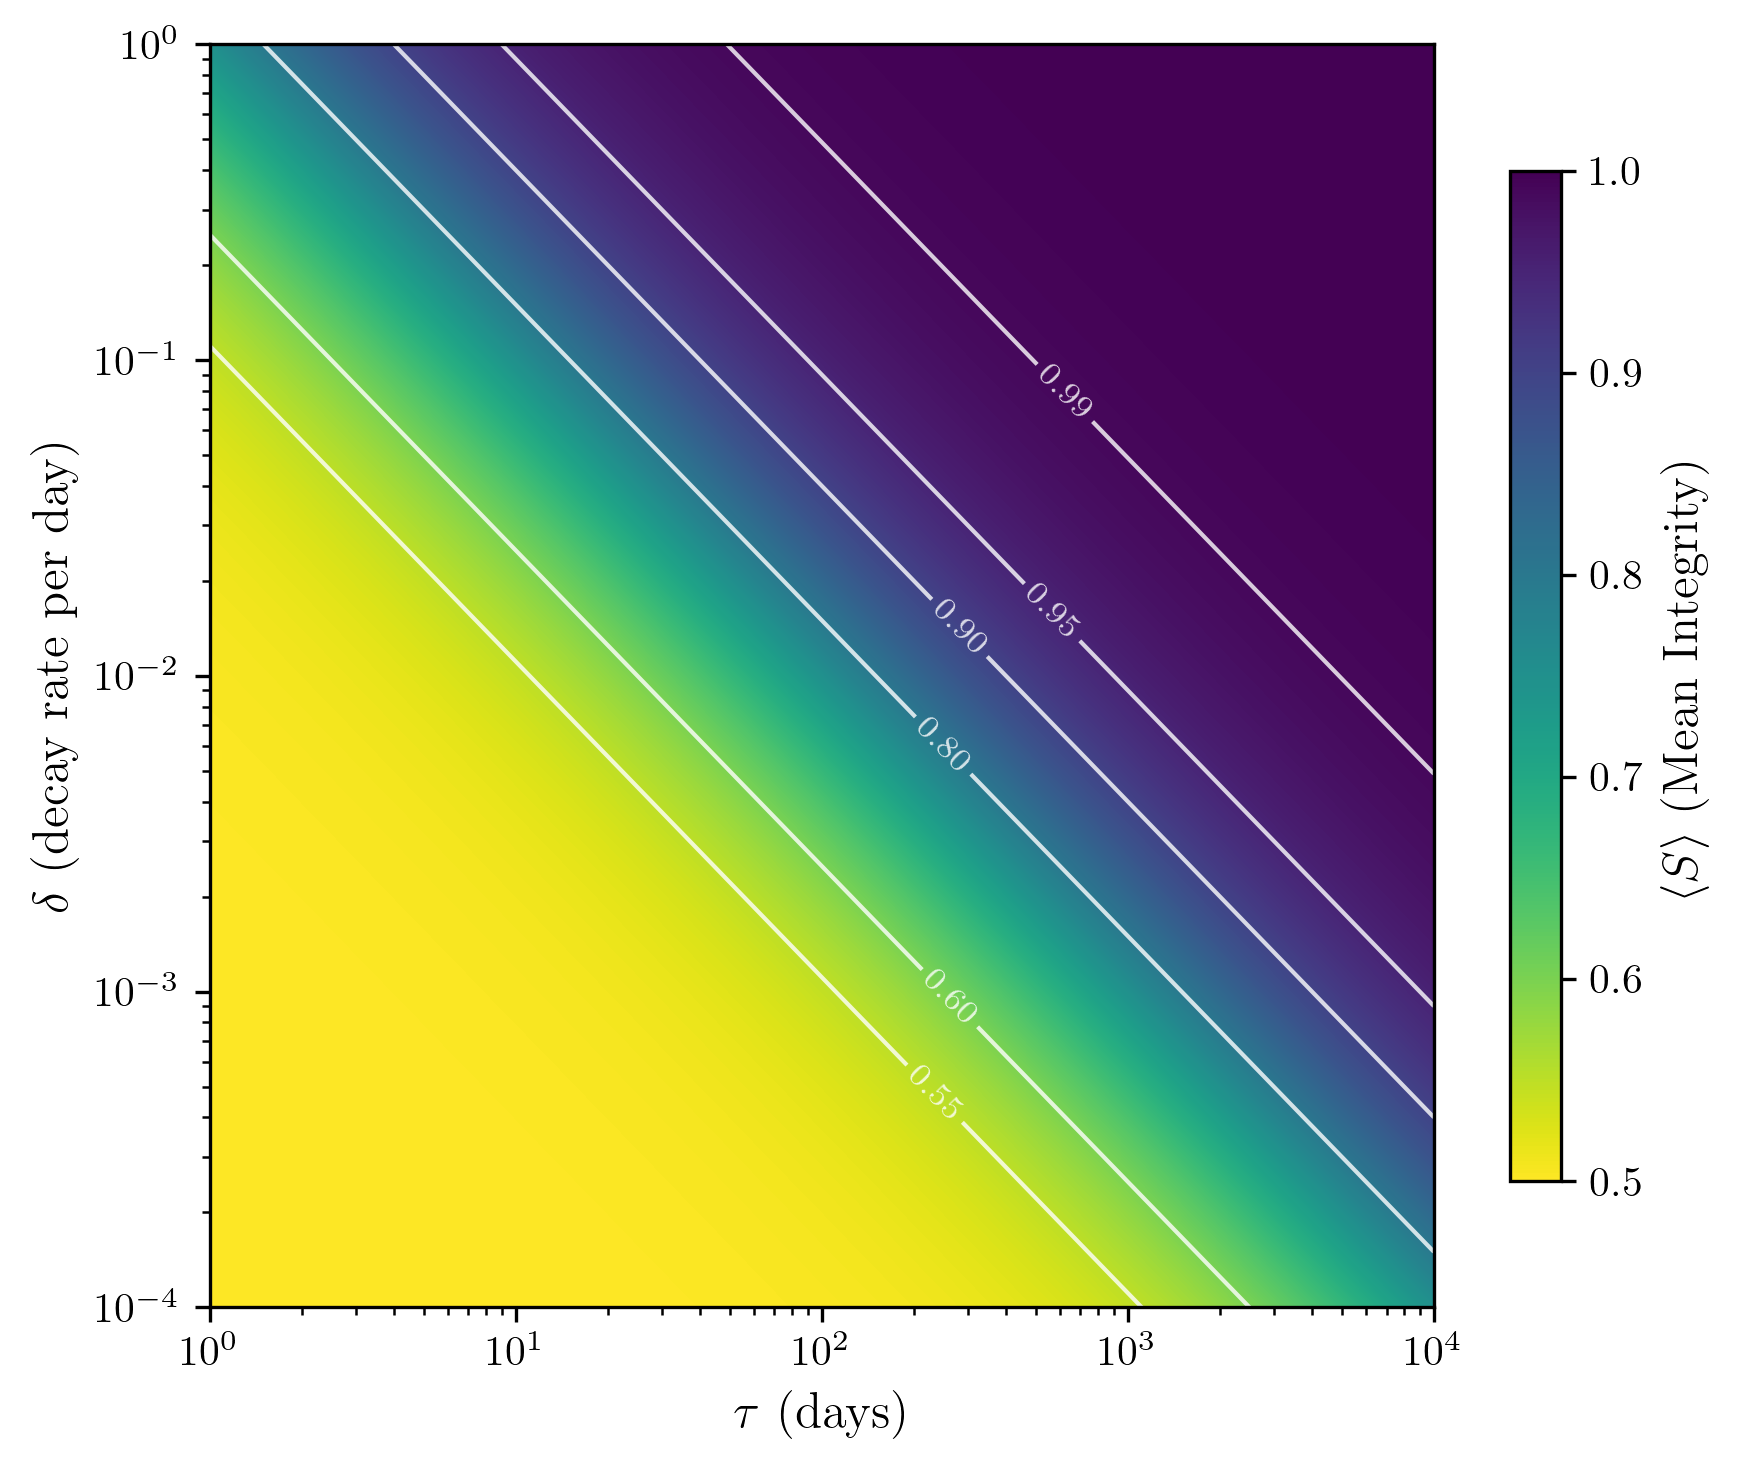

In [5]:
# --- Parameter ranges (log-spaced for tau, log-spaced for decay) ---
tau = np.logspace(0, 4, num=5000)          # 1 to 10^5
decay_rate = np.logspace(-4, 0, num=5000)  # 1e-4 to 1

# --- Create 2D grid ---
TAU, DELTA = np.meshgrid(tau, decay_rate, indexing='xy')

# --- Evaluate function ---
S_2 = equilibrium_constant_decay(TAU, DELTA)

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

# Use pcolormesh for proper log-axis rendering
# pcolormesh expects coordinates at cell edges, so compute edges
tau_edges = np.logspace(0, 4, num=5001)
decay_edges = np.logspace(-4, 0, num=5001)

im = ax.pcolormesh(tau_edges, decay_edges, S_2, 
                   shading='auto', cmap='viridis_r', vmin=0.5, vmax=1.0)

# --- Log scales on BOTH axes ---
ax.set_xscale('log')
ax.set_yscale('log')

# --- Colorbar ---
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)

# --- Labels ---
ax.set_ylabel(r'$\delta$ (decay rate per day)', fontsize=12)
ax.set_xlabel(r'$\tau$ (days)', fontsize=12)


# --- Contour lines (white, labeled) ---
contour_levels = [0.55,0.6, 0.8, 0.9, 0.95, 0.99]
contours = ax.contour(TAU, DELTA, S_2, levels=contour_levels,
                      colors='white', linewidths=1.0, alpha=0.8)
ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f', colors='white')

plt.tight_layout()
#plt.savefig('equilibrium_constant_heatmap_loglog.png', dpi=300)
plt.show()


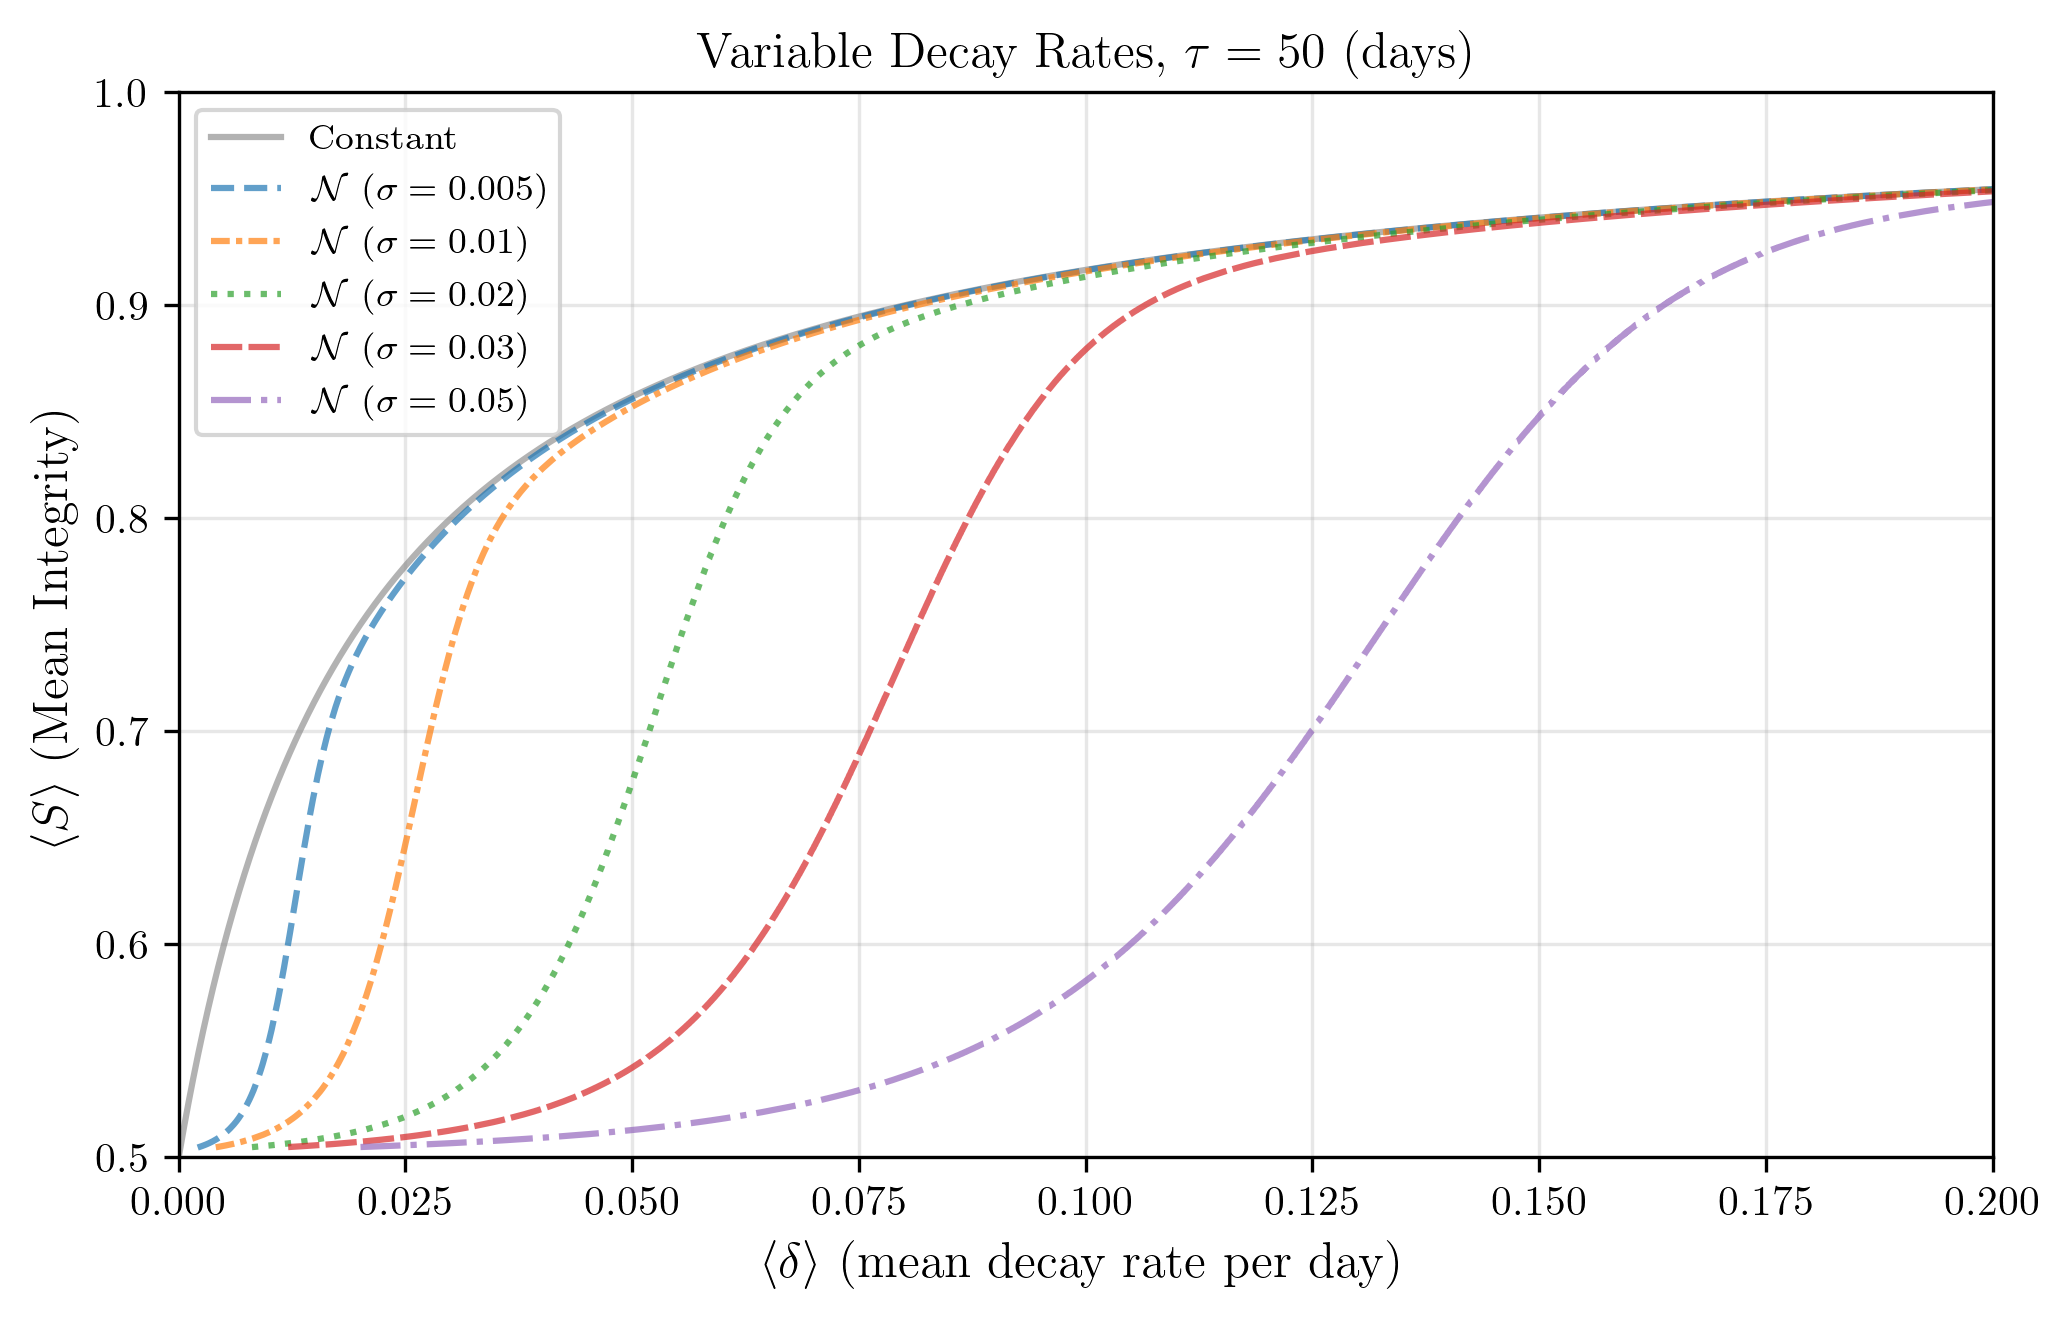

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad_vec
from scipy.stats import norm

def clipped_normal_moments(mu_arr, sigma, a):
    """
    Exact mean and mean inverse of a normal distribution N(mu, sigma^2)
    clipped at the floor delta = a: any value drawn below a is set to a,
    giving a continuous part on [a, inf) plus a point mass at a.

    For each mu in mu_arr, returns:
        x_real    -- realized mean decay rate <delta> after clipping
        mean_inv  -- mean inverse decay rate <1/delta>, the quantity that
                     controls mean integrity in the equilibrium expression
    """
    # Ensure mu_arr is a float array so elementwise operations work below
    mu_arr = np.asarray(mu_arr, dtype=float)

    # Position of the floor in standard-normal units, for each mu
    u0 = (a - mu_arr) / sigma

    # Phi = probability mass falling below the floor (piled up at delta = a)
    # Z   = probability mass above the floor (the continuous part)
    Phi, Z = norm.cdf(u0), norm.sf(u0)

    def integrand(u):
        # phi(u) / (mu + sigma*u): the integrand of <1/delta> written in
        # standard-normal units, since delta = mu + sigma*u
        u = np.atleast_1d(u)
        vals = norm.pdf(u)[None, :] / (mu_arr[:, None] + sigma * u[None, :])
        # Zero out the part of the domain below each mu's floor, so the
        # integral over the shared grid covers only the continuous part
        vals[u[None, :] < u0[:, None]] = 0.0
        return vals

    # Numerically integrate over u from the lowest floor up to 8 standard
    # deviations (beyond which the normal density is negligible), for all
    # mu values simultaneously
    I, _ = quad_vec(integrand, u0.min(), 8, epsabs=1e-10, epsrel=1e-9, limit=300)

    # quad_vec returns one column per mu; flatten to a 1-D array
    I = np.asarray(I).reshape(len(mu_arr), -1)[:, 0]

    # <1/delta>: contribution from the point mass (probability Phi, each
    # contributing 1/a) plus the integral over the continuous part
    mean_inv = (Phi/a) + I

    # <delta>: contribution from the point mass (Phi * a) plus the standard
    # result for the partial mean of a normal above a threshold
    x_real = Phi * a + mu_arr * Z + sigma * norm.pdf(u0)

    return x_real, mean_inv

tau = 50
delta_min = 0.0001   # lower truncation floor for the decay-rate distributions
mean_decays = np.linspace(0.0001, 0.2, num=4000)

fig, ax = plt.subplots(figsize=(7, 4.5))

# Constant
ax.plot(mean_decays, (2 * tau + 1.0 / mean_decays) / (2 * tau + 2.0 / mean_decays),
        linewidth=1.5, ls='-', label='Constant', color='grey', alpha=0.6)

linestyles = {
    r'$\mathcal{N}$ ($\sigma=0.005$)': '--',
    r'$\mathcal{N}$ ($\sigma=0.01$)': (0, (3, 1, 1, 1)),
    r'$\mathcal{N}$ ($\sigma=0.02$)': ':',
    r'$\mathcal{N}$ ($\sigma=0.03$)': (0, (5, 1)),
    r'$\mathcal{N}$ ($\sigma=0.05$)': '-.',
}

# Normals (exact numerical integration, no sampling)
for sigma, label in [(0.005, r'$\mathcal{N}$ ($\sigma=0.005$)'),
                     (0.01, r'$\mathcal{N}$ ($\sigma=0.01$)'),
                     (0.02, r'$\mathcal{N}$ ($\sigma=0.02$)'),
                     (0.03, r'$\mathcal{N}$ ($\sigma=0.03$)'),
                     (0.05, r'$\mathcal{N}$ ($\sigma=0.05$)')]:
    x_real, mean_inv_delta = clipped_normal_moments(mean_decays, sigma, delta_min)
    S = (2 * tau + mean_inv_delta) / (2 * tau + 2 * mean_inv_delta)
    ax.plot(x_real, S, linewidth=1.5, ls=linestyles[label], label=label, alpha=0.7)

ax.set_xlabel(r'$\langle \delta \rangle$ (mean decay rate per day)', fontsize=12)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
ax.set_title(rf'Variable Decay Rates, $\tau = {tau}$ (days)', fontsize=12)
ax.set_xlim([0.0, 0.2])
ax.set_ylim([0.5, 1.0])

ax.legend(fontsize=8.5, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("paper_figure_draft_variable_decay_rates.png")
plt.show()

Code for testing the decerlertaing exponetial model which using a $$ \frac{dS}{dt} = - \delta - \alpha S$$ decay rate

In [7]:
import numpy as np

def decelerate_snapshot_preservation(tau, delta, alpha):
    """
    Compute the decelerate mixed-model snapshot preservation <S> for given
    lifespan tau, intrinsic decay delta, and environmental degradation alpha.
    
    Parameters
    ----------
    tau : float or array_like
        Nominal lifespan (tau = 1/mu).
    delta : float or array_like
        Intrinsic decay rate (must be > 0).
    alpha : float or array_like
        Environmental degradation rate (alpha >= 0).
    
    Returns
    -------
    S : ndarray
        Snapshot preservation level.  Broadcasts over all inputs.
    """
    # Convert to arrays with common broadcasting shape
    tau   = np.asarray(tau, dtype=float)
    delta = np.asarray(delta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    
    # Broadcast to common shape
    tau, delta, alpha = np.broadcast_arrays(tau, delta, alpha)
    
    # Output array
    S = np.empty_like(tau, dtype=float)
    
    # ------------------------------------------------------------------
    # Case 1: alpha == 0  (original linear model)
    # ------------------------------------------------------------------
    mask_linear = (alpha == 0)
    if np.any(mask_linear):
        S[mask_linear] = (2.0 * tau[mask_linear] * delta[mask_linear] + 1.0) \
                         / (2.0 * tau[mask_linear] * delta[mask_linear] + 2.0)
    
    # ------------------------------------------------------------------
    # Case 2: alpha > 0  (mixed model)
    # ------------------------------------------------------------------
    mask_mixed = ~mask_linear
    if not np.any(mask_mixed):
        return S
    
    t = tau[mask_mixed]
    d = delta[mask_mixed]
    a = alpha[mask_mixed]
    
    x = a / d  # ratio alpha/delta
    
    # For very small x, use series expansion to avoid catastrophic
    # cancellation in 1 - (1/x)*log1p(x).
    # log1p(x) = x - x^2/2 + x^3/3 - x^4/4 + ...
    # (1/x)*log1p(x) = 1 - x/2 + x^2/3 - x^3/4 + ...
    # 1 - (1/x)*log1p(x) = x/2 - x^2/3 + x^3/4 - ...
    
    small_x = x < 1e-8
    large_x = ~small_x
    
    # Pre-allocate the bracket term: 1 - (delta/alpha)*ln(1+alpha/delta)
    bracket = np.empty_like(x)
    
    if np.any(large_x):
        xl = x[large_x]
        bracket[large_x] = 1.0 - (1.0 / xl) * np.log1p(xl)
    
    if np.any(small_x):
        xs = x[small_x]
        # Series: xs/2 - xs^2/3 + xs^3/4 - xs^4/5 + ...
        bracket[small_x] = xs * (0.5 - xs * (1.0/3.0 - xs * (0.25 - xs * 0.2)))
    
    # ln(1 + alpha/delta)
    log_term = np.log1p(x)
    
    # Numerator and denominator
    num = 1.0 + (1.0 / (a * t)) * bracket
    den = 1.0 + (1.0 / (a * t)) * log_term
    
    S[mask_mixed] = num / den
    
    return S

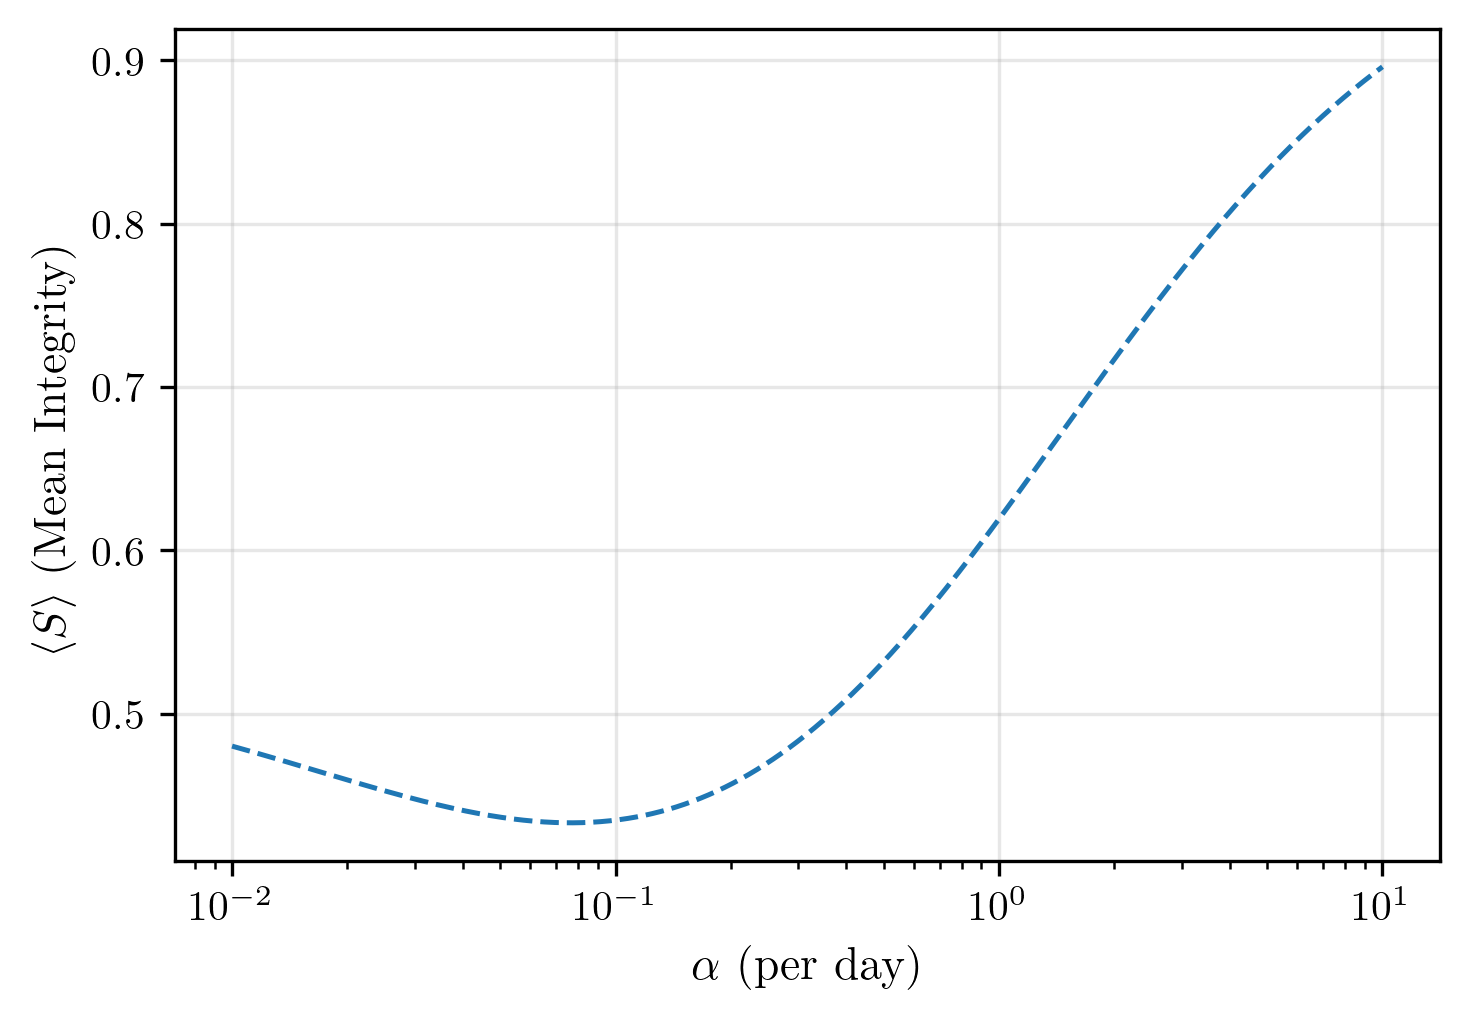

In [8]:
alpha  = np.logspace(-2, 1, num =1000)

delta = 0.01

tau = 5

#decay_rate = 0.01
S_4 = decelerate_snapshot_preservation(tau, delta, alpha)




fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(alpha , S_4,  linewidth=1.2, ls="--")

ax.set_xlabel(r'$\alpha$ (per day)', fontsize=11)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=11)
#ax.set_title(r'$\tau = 50$', fontsize=11)
ax.set_xscale('log')

#ax.set_ylim([0.5, 1.0])  # Function asymptotes to 1
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('equilibrium_constant_lifespan_preservation.png', dpi=300)
plt.show()





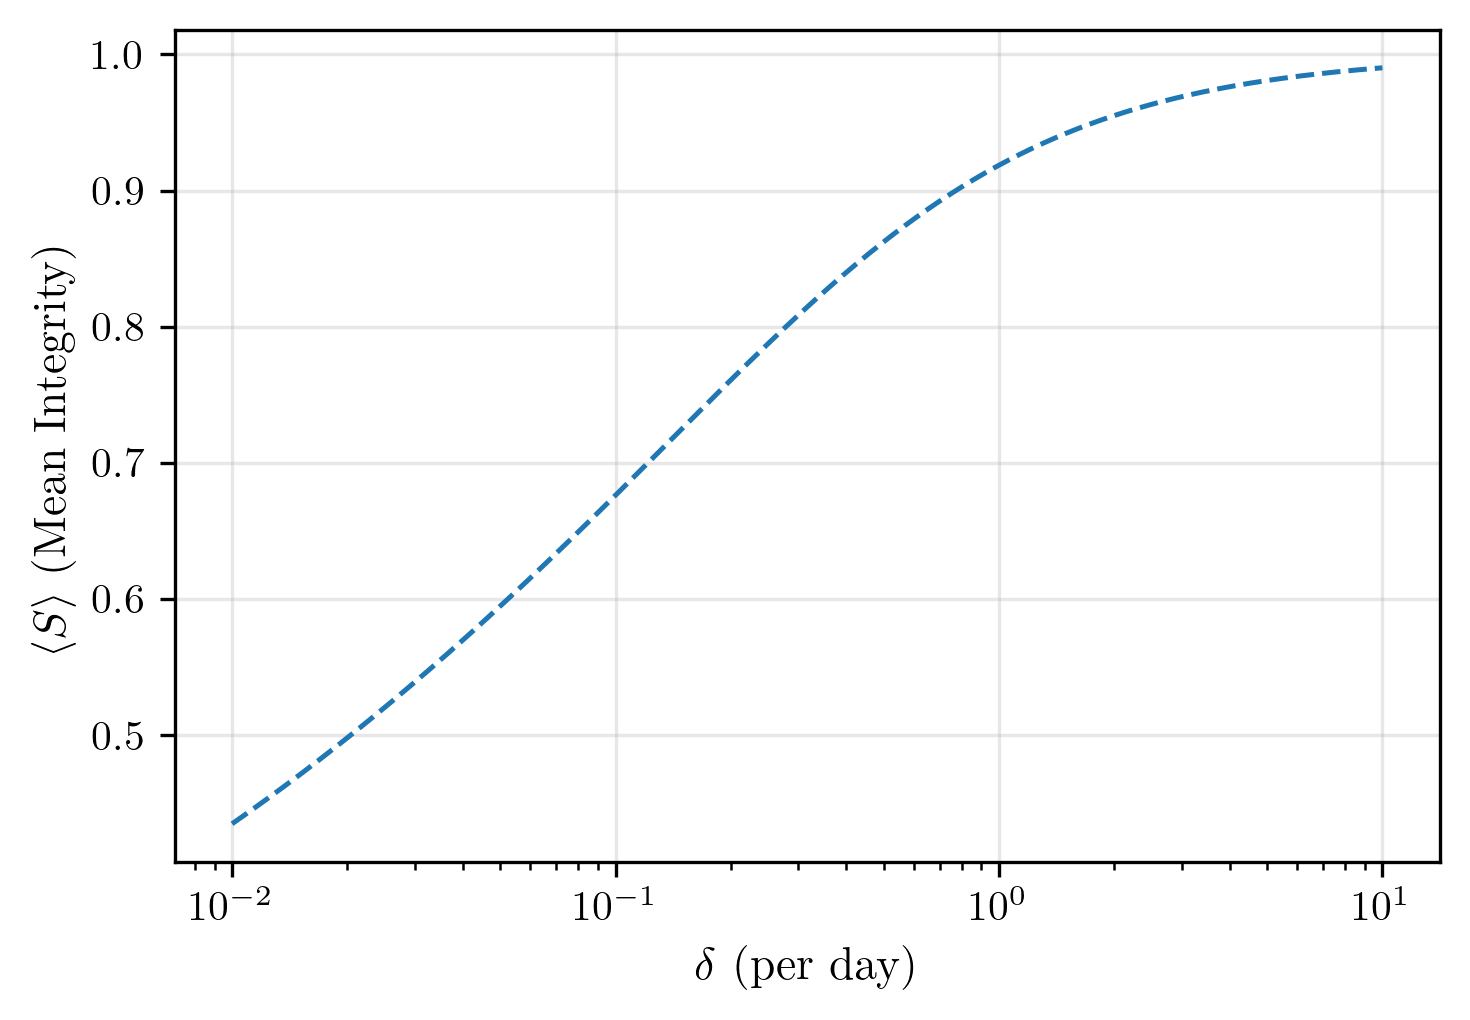

In [9]:
alpha  = 0.1

delta = np.logspace(-2, 1, num =1000)

tau = 5

#decay_rate = 0.01
S_4 = decelerate_snapshot_preservation(tau, delta, alpha)




fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(delta , S_4,  linewidth=1.2, ls="--")

ax.set_xlabel(r'$\delta$ (per day)', fontsize=11)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=11)
#ax.set_title(r'$\tau = 50$', fontsize=11)
ax.set_xscale('log')

#ax.set_ylim([0.5, 1.0])  # Function asymptotes to 1
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('equilibrium_constant_lifespan_preservation.png', dpi=300)
plt.show()

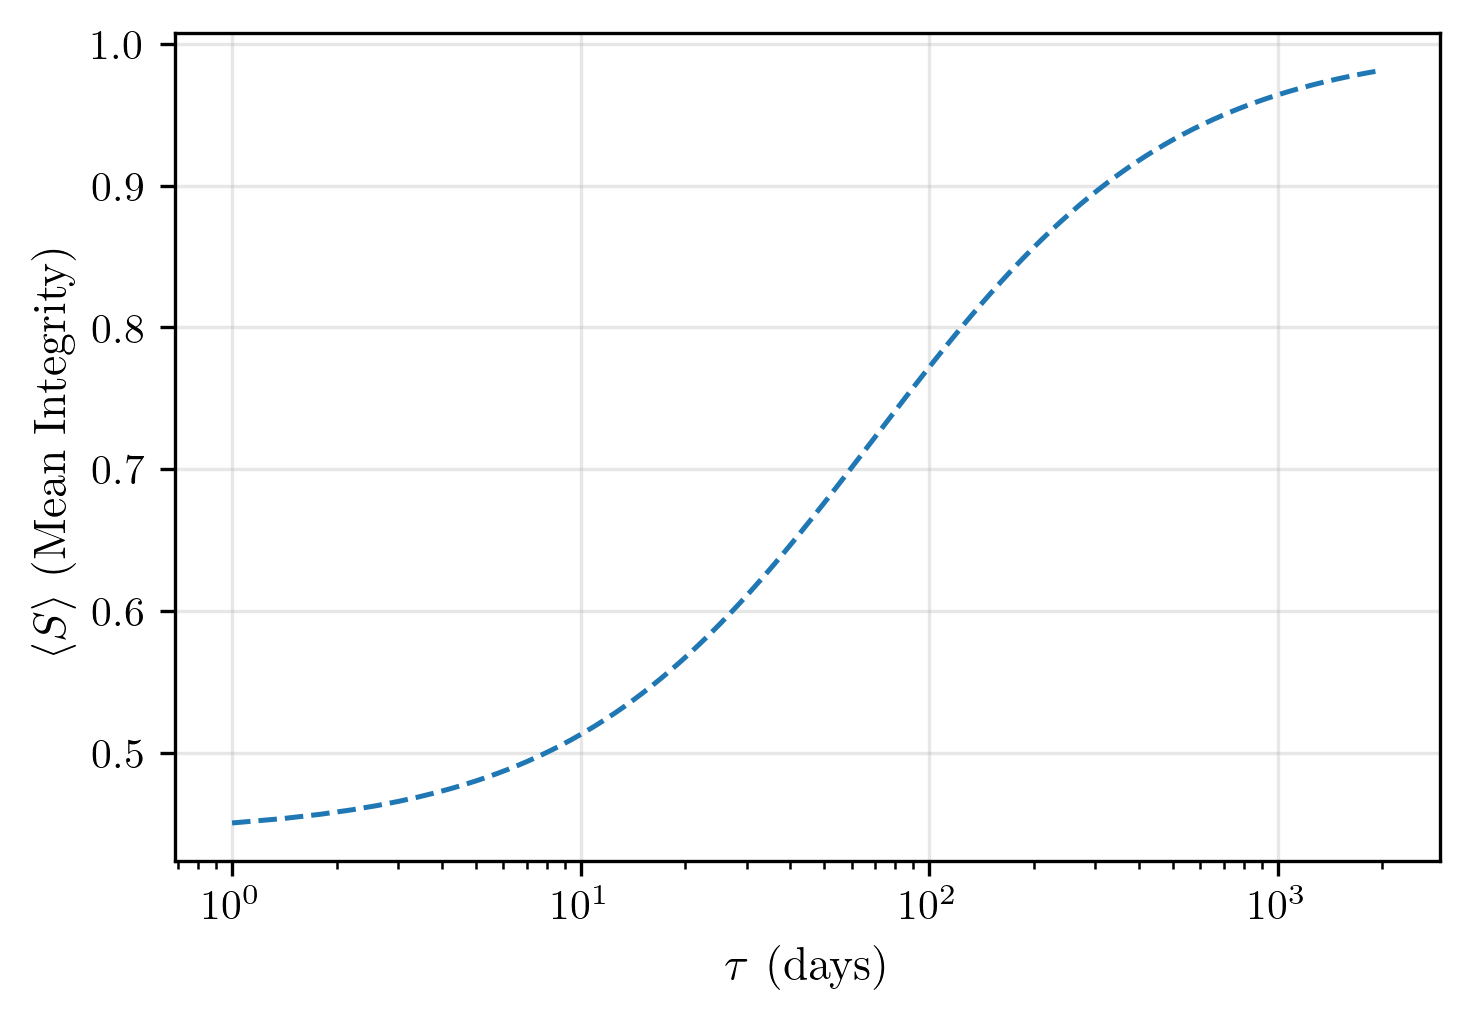

In [10]:
alpha  = 0.01

delta = 0.01

tau = np.linspace(1, 2000, num =5000)

#decay_rate = 0.01
S_5 = decelerate_snapshot_preservation(tau, delta, alpha)




fig, ax = plt.subplots(figsize=(5, 3.5))

ax.plot(tau , S_5,  linewidth=1.2, ls="--")

ax.set_xlabel(r'$\tau$ (days)', fontsize=11)
ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=11)
#ax.set_title(r'$\tau = 50$', fontsize=11)
ax.set_xscale('log')

#ax.set_ylim([0.5, 1.0])  # Function asymptotes to 1
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('equilibrium_constant_lifespan_preservation.png', dpi=300)
plt.show()

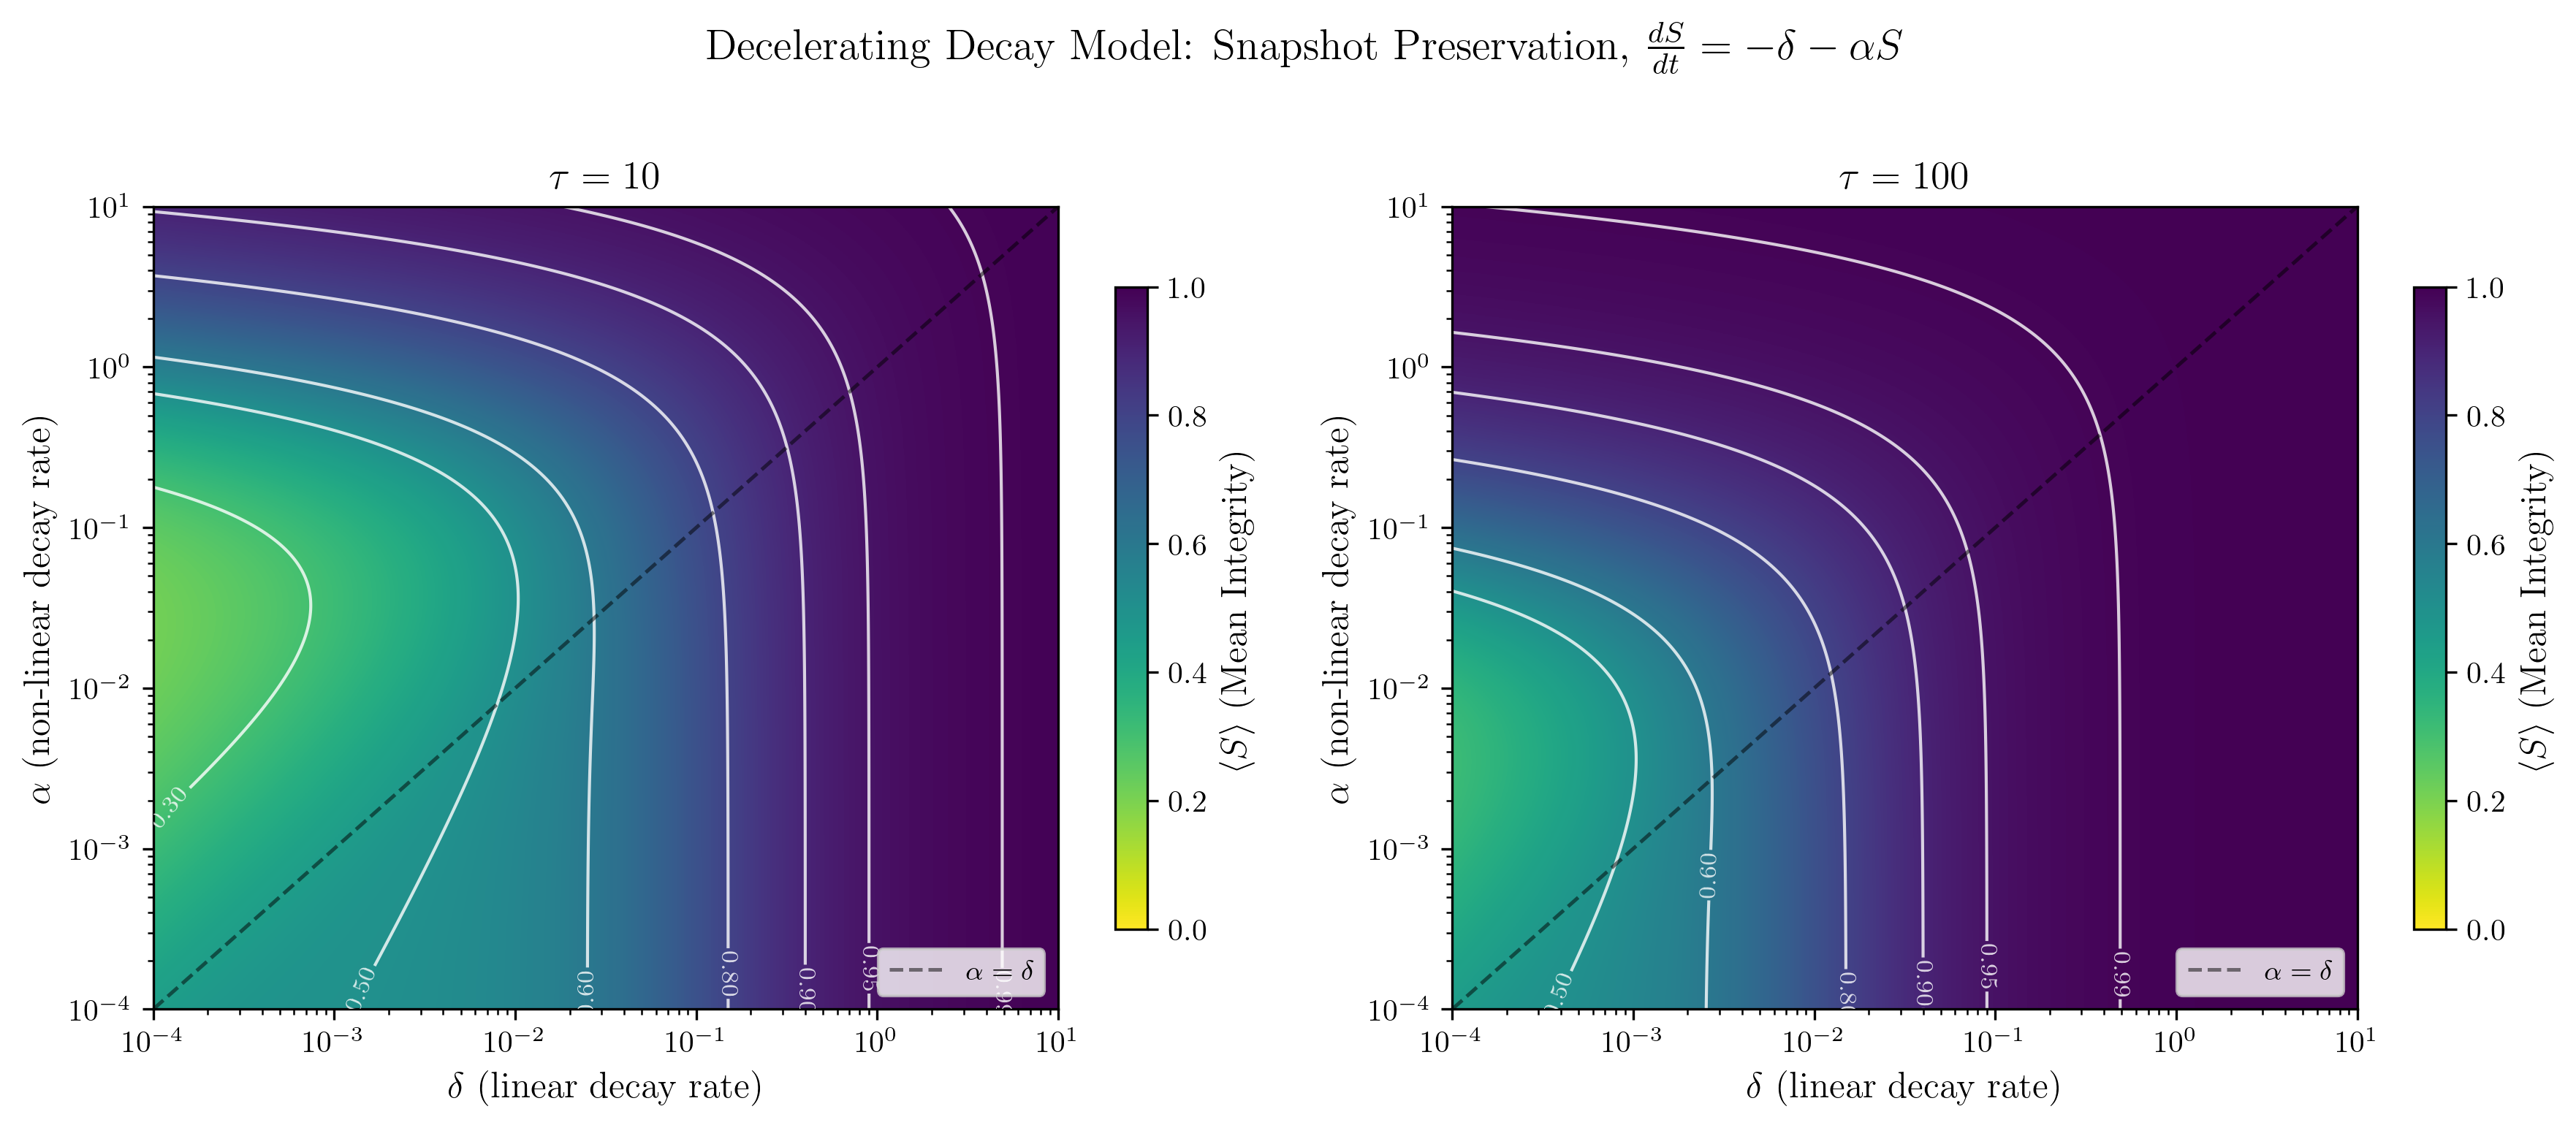

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def decelerate_snapshot_preservation(tau, delta, alpha):
    """
    Compute the mixed-model snapshot preservation <S> for given
    lifespan tau, intrinsic decay delta, and environmental degradation alpha.
    
    Parameters
    ----------
    tau : float or array_like
        Nominal lifespan (tau = 1/mu).
    delta : float or array_like
        Intrinsic decay rate (must be > 0).
    alpha : float or array_like
        Environmental degradation rate (alpha >= 0).
    
    Returns
    -------
    S : ndarray
        Snapshot preservation level.  Broadcasts over all inputs.
    """
    tau   = np.asarray(tau, dtype=float)
    delta = np.asarray(delta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    
    # Broadcast to common shape
    tau, delta, alpha = np.broadcast_arrays(tau, delta, alpha)
    S = np.empty_like(tau, dtype=float)
    
    # Case 1: alpha == 0  (original linear model)
    mask_linear = (alpha == 0)
    if np.any(mask_linear):
        S[mask_linear] = (2.0 * tau[mask_linear] * delta[mask_linear] + 1.0) \
                         / (2.0 * tau[mask_linear] * delta[mask_linear] + 2.0)
    
    # Case 2: alpha > 0  (mixed model)
    mask_mixed = ~mask_linear
    if not np.any(mask_mixed):
        return S
    
    t = tau[mask_mixed]
    d = delta[mask_mixed]
    a = alpha[mask_mixed]
    
    x = a / d  # ratio alpha/delta
    
    # For very small x, use series expansion to avoid catastrophic cancellation
    small_x = x < 1e-8
    large_x = ~small_x
    
    # Bracket term: 1 - (delta/alpha)*ln(1+alpha/delta)
    bracket = np.empty_like(x)
    
    if np.any(large_x):
        xl = x[large_x]
        bracket[large_x] = 1.0 - (1.0 / xl) * np.log1p(xl)
    
    if np.any(small_x):
        xs = x[small_x]
        bracket[small_x] = xs * (0.5 - xs * (1.0/3.0 - xs * (0.25 - xs * 0.2)))
    
    log_term = np.log1p(x)
    
    num = 1.0 + (1.0 / (a * t)) * bracket
    den = 1.0 + (1.0 / (a * t)) * log_term
    
    S[mask_mixed] = num / den
    
    return S


# --- Parameter ranges (log-spaced for alpha and delta) ---
delta = np.logspace(-4, 1, num=2000)   # 1e-4 to 10
alpha = np.logspace(-4, 1, num=2000)   # 1e-4 to 10

# --- Fixed tau values for comparison ---
tau_values = [10, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    # Create 2D grid
    DELTA, ALPHA = np.meshgrid(delta, alpha, indexing='xy')
    
    # Evaluate mixed model
    S_mixed = decelerate_snapshot_preservation(tau, DELTA, ALPHA)
    
    # pcolormesh expects coordinates at cell edges
    delta_edges = np.logspace(-4, 1, num=2001)
    alpha_edges = np.logspace(-4, 1, num=2001)
    
    # Plot heatmap
    im = ax.pcolormesh(delta_edges, alpha_edges, S_mixed, 
                       shading='auto', cmap='viridis_r', vmin=0.0, vmax=1.0)
    
    # Log scales on both axes
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    # Labels
    ax.set_xlabel(r'$\delta$ (linear decay rate)', fontsize=12)
    ax.set_ylabel(r'$\alpha$ (non-linear decay rate)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    
    # Contour lines (white, labeled)
    contour_levels = [0.2, 0.3, 0.5, 0.6, 0.8, 0.9, 0.95, 0.99]
    contours = ax.contour(DELTA, ALPHA, S_mixed, levels=contour_levels,
                          colors='white', linewidths=1.0, alpha=0.8)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f', colors='white')
    
    # Diagonal reference line alpha = delta
    ax.plot(delta, delta, 'k--', linewidth=1.2, alpha=0.5, label=r'$\alpha = \delta$')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle(r'Decelerating Decay Model: Snapshot Preservation, $ \frac{dS}{dt} = - \delta - \alpha S$', fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('exponetial_model_quicktest_heatmap.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_decelerating_decay_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()

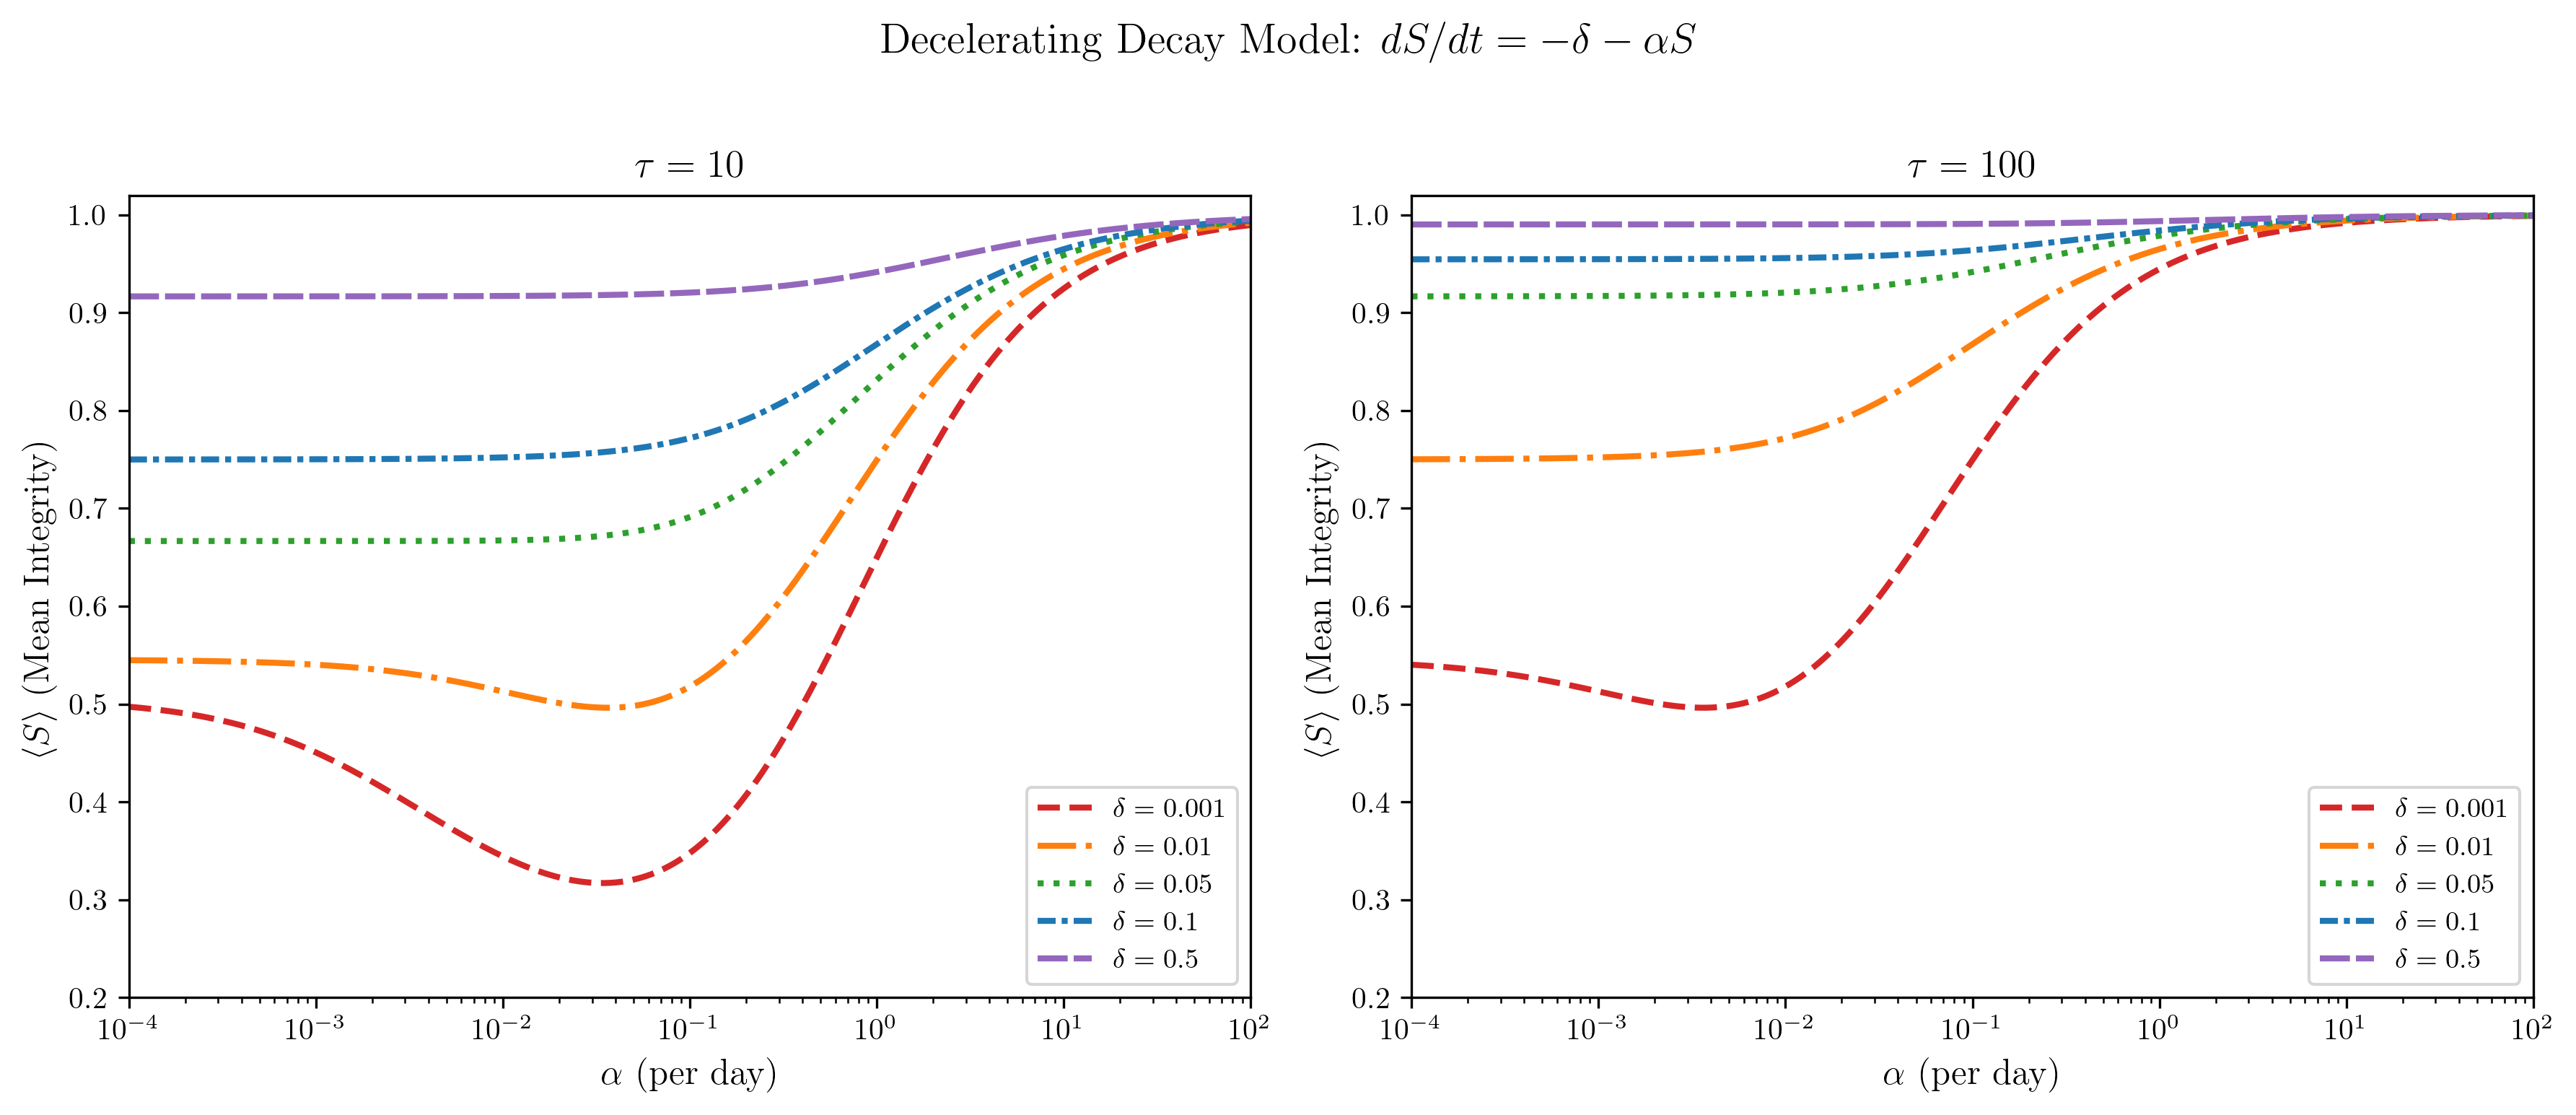

In [12]:
# --- Plot settings ---
tau_values = [10, 100]
deltas = [0.001, 0.01, 0.05, 0.1, 0.5]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
alpha_vals = np.logspace(-4, 2, 2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    for delta, color, ls in zip(deltas, colors,  linestyles):
        S = decelerate_snapshot_preservation(tau, delta, alpha_vals)
        ax.plot(alpha_vals, S, color=color, linewidth=2, label=rf'$\delta = {delta}$', ls =ls)
        

    
    # Reference lines
    #ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, 
    #           label=r'$\langle S \rangle = 0.5$')
    #ax.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_xlabel(r'$\alpha$ (per day)', fontsize=12)
    ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    ax.set_ylim(0.2, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    #ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(alpha_vals.min(), alpha_vals.max())
plt.suptitle(r' Decelerating Decay Model: $dS/dt = -\delta - \alpha S$', 
             fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('example_Non_linear_decay_model_lines.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_decelerating_decay_alpha.png", bbox_inches='tight', dpi=300)
plt.show()

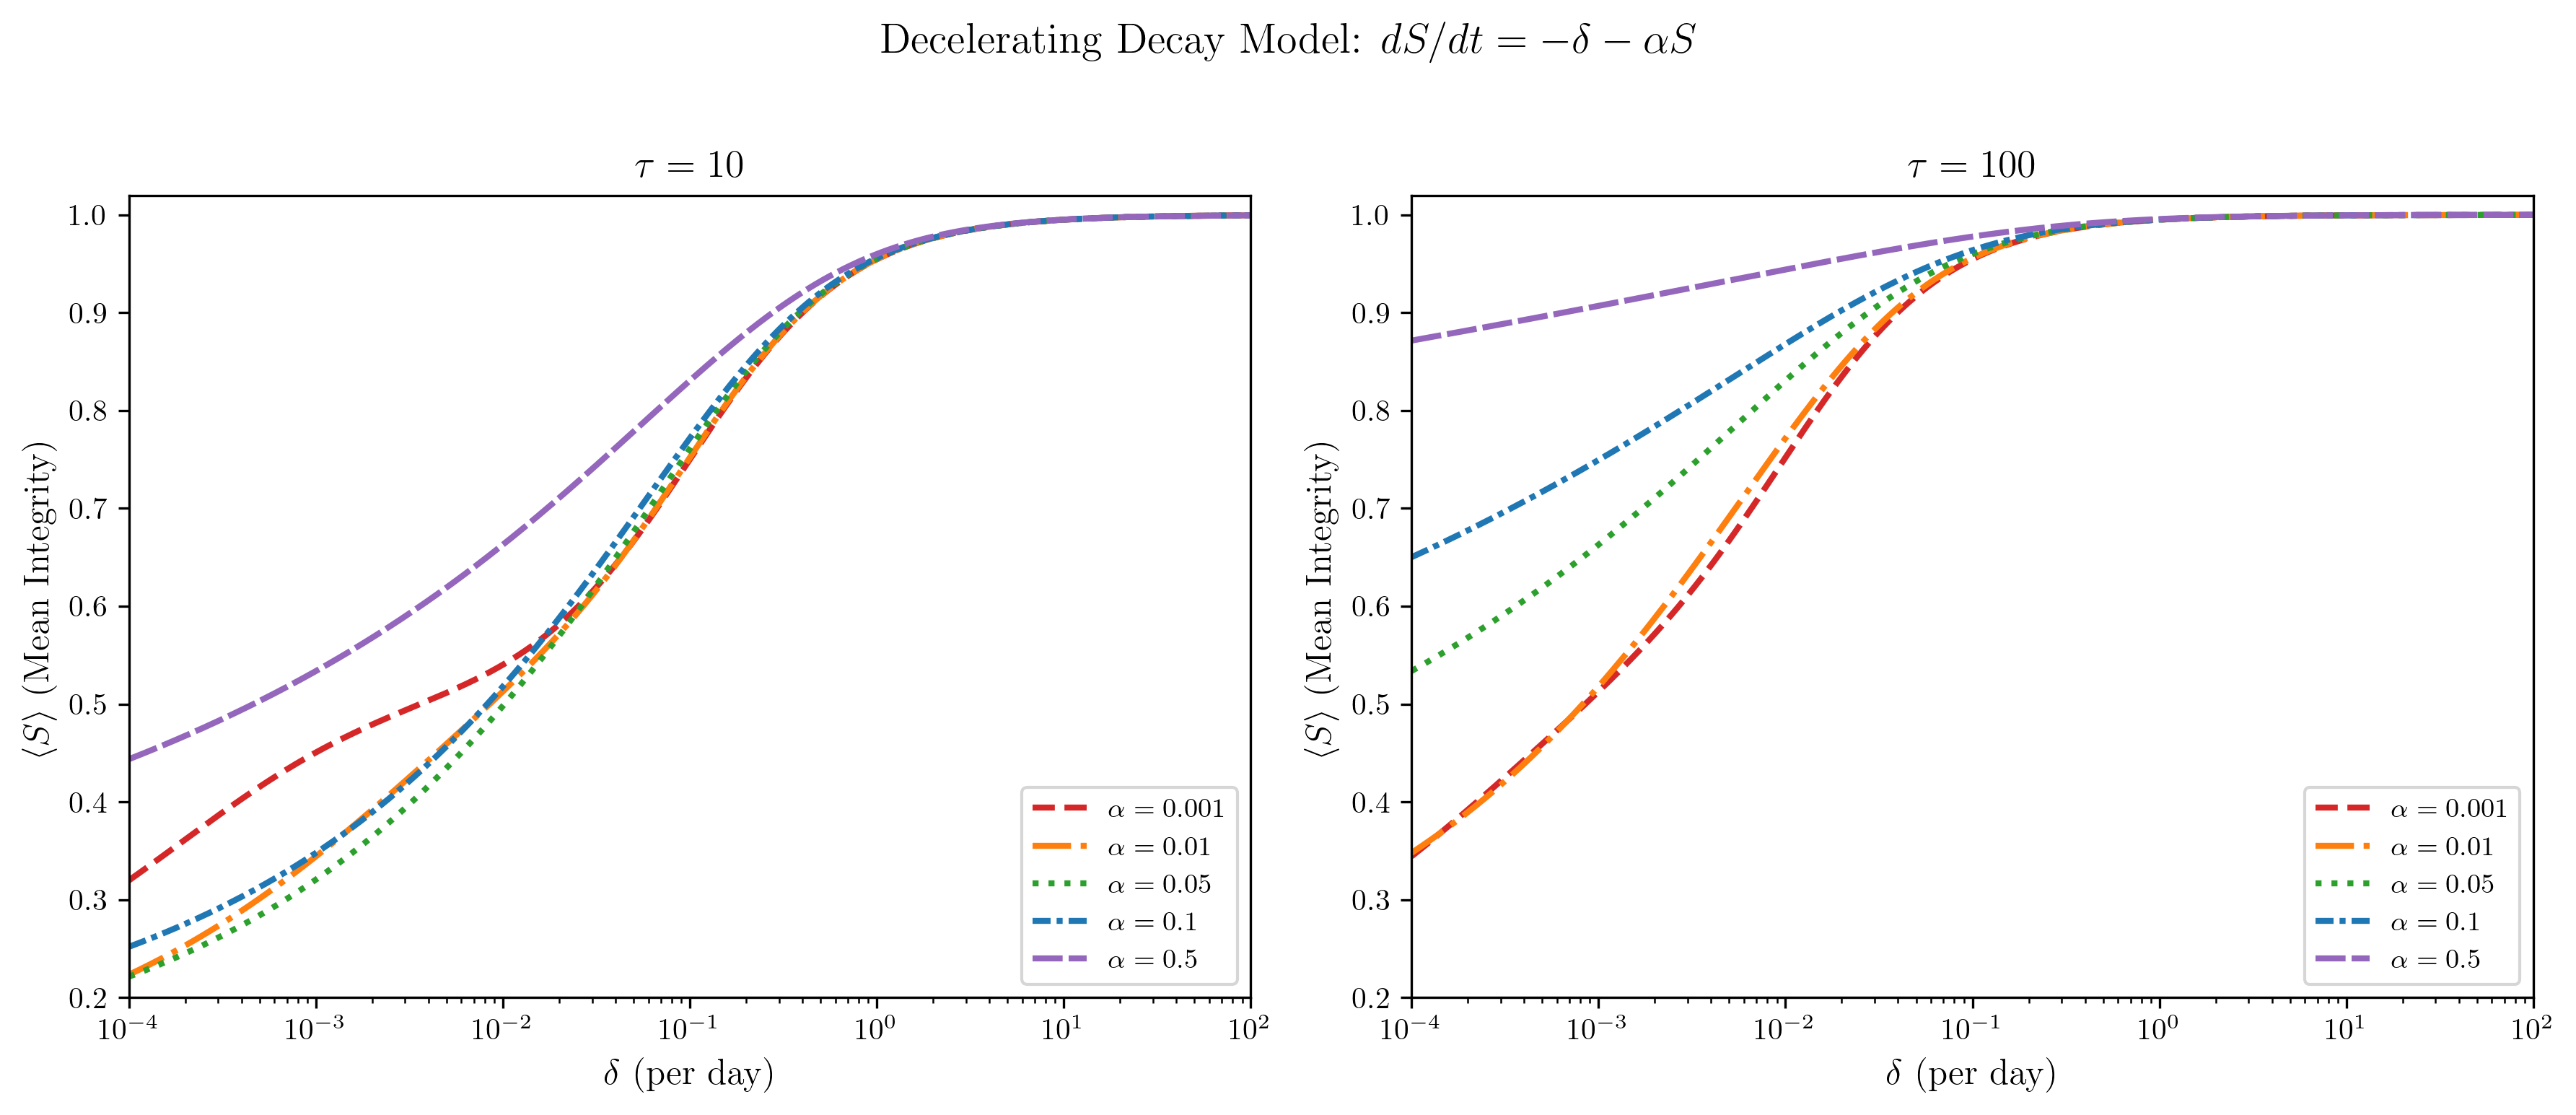

In [13]:
# --- Plot settings ---
tau_values = [10, 100]
alphas = [0.001, 0.01, 0.05, 0.1, 0.5]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
deltas_vals = np.logspace(-4, 2, 2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    for alpha, color, ls in zip(alphas, colors,  
                                linestyles):
        S = decelerate_snapshot_preservation(tau, deltas_vals, alpha)
        ax.plot(deltas_vals, S, color=color, linewidth=2, label=rf'$\alpha = {alpha}$', ls =ls)
        

    
    # Reference lines
    #ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, 
    #           label=r'$\langle S \rangle = 0.5$')
    #ax.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_xlabel(r'$\delta$ (per day)', fontsize=12)
    ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    ax.set_ylim(0.2, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    #ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(deltas_vals.min(), deltas_vals.max())
plt.suptitle(r' Decelerating Decay Model: $dS/dt = -\delta - \alpha S$', 
             fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('example_Non_linear_decay_model_lines.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_decelerating_decay_delta.png", bbox_inches='tight', dpi=300)
plt.show()

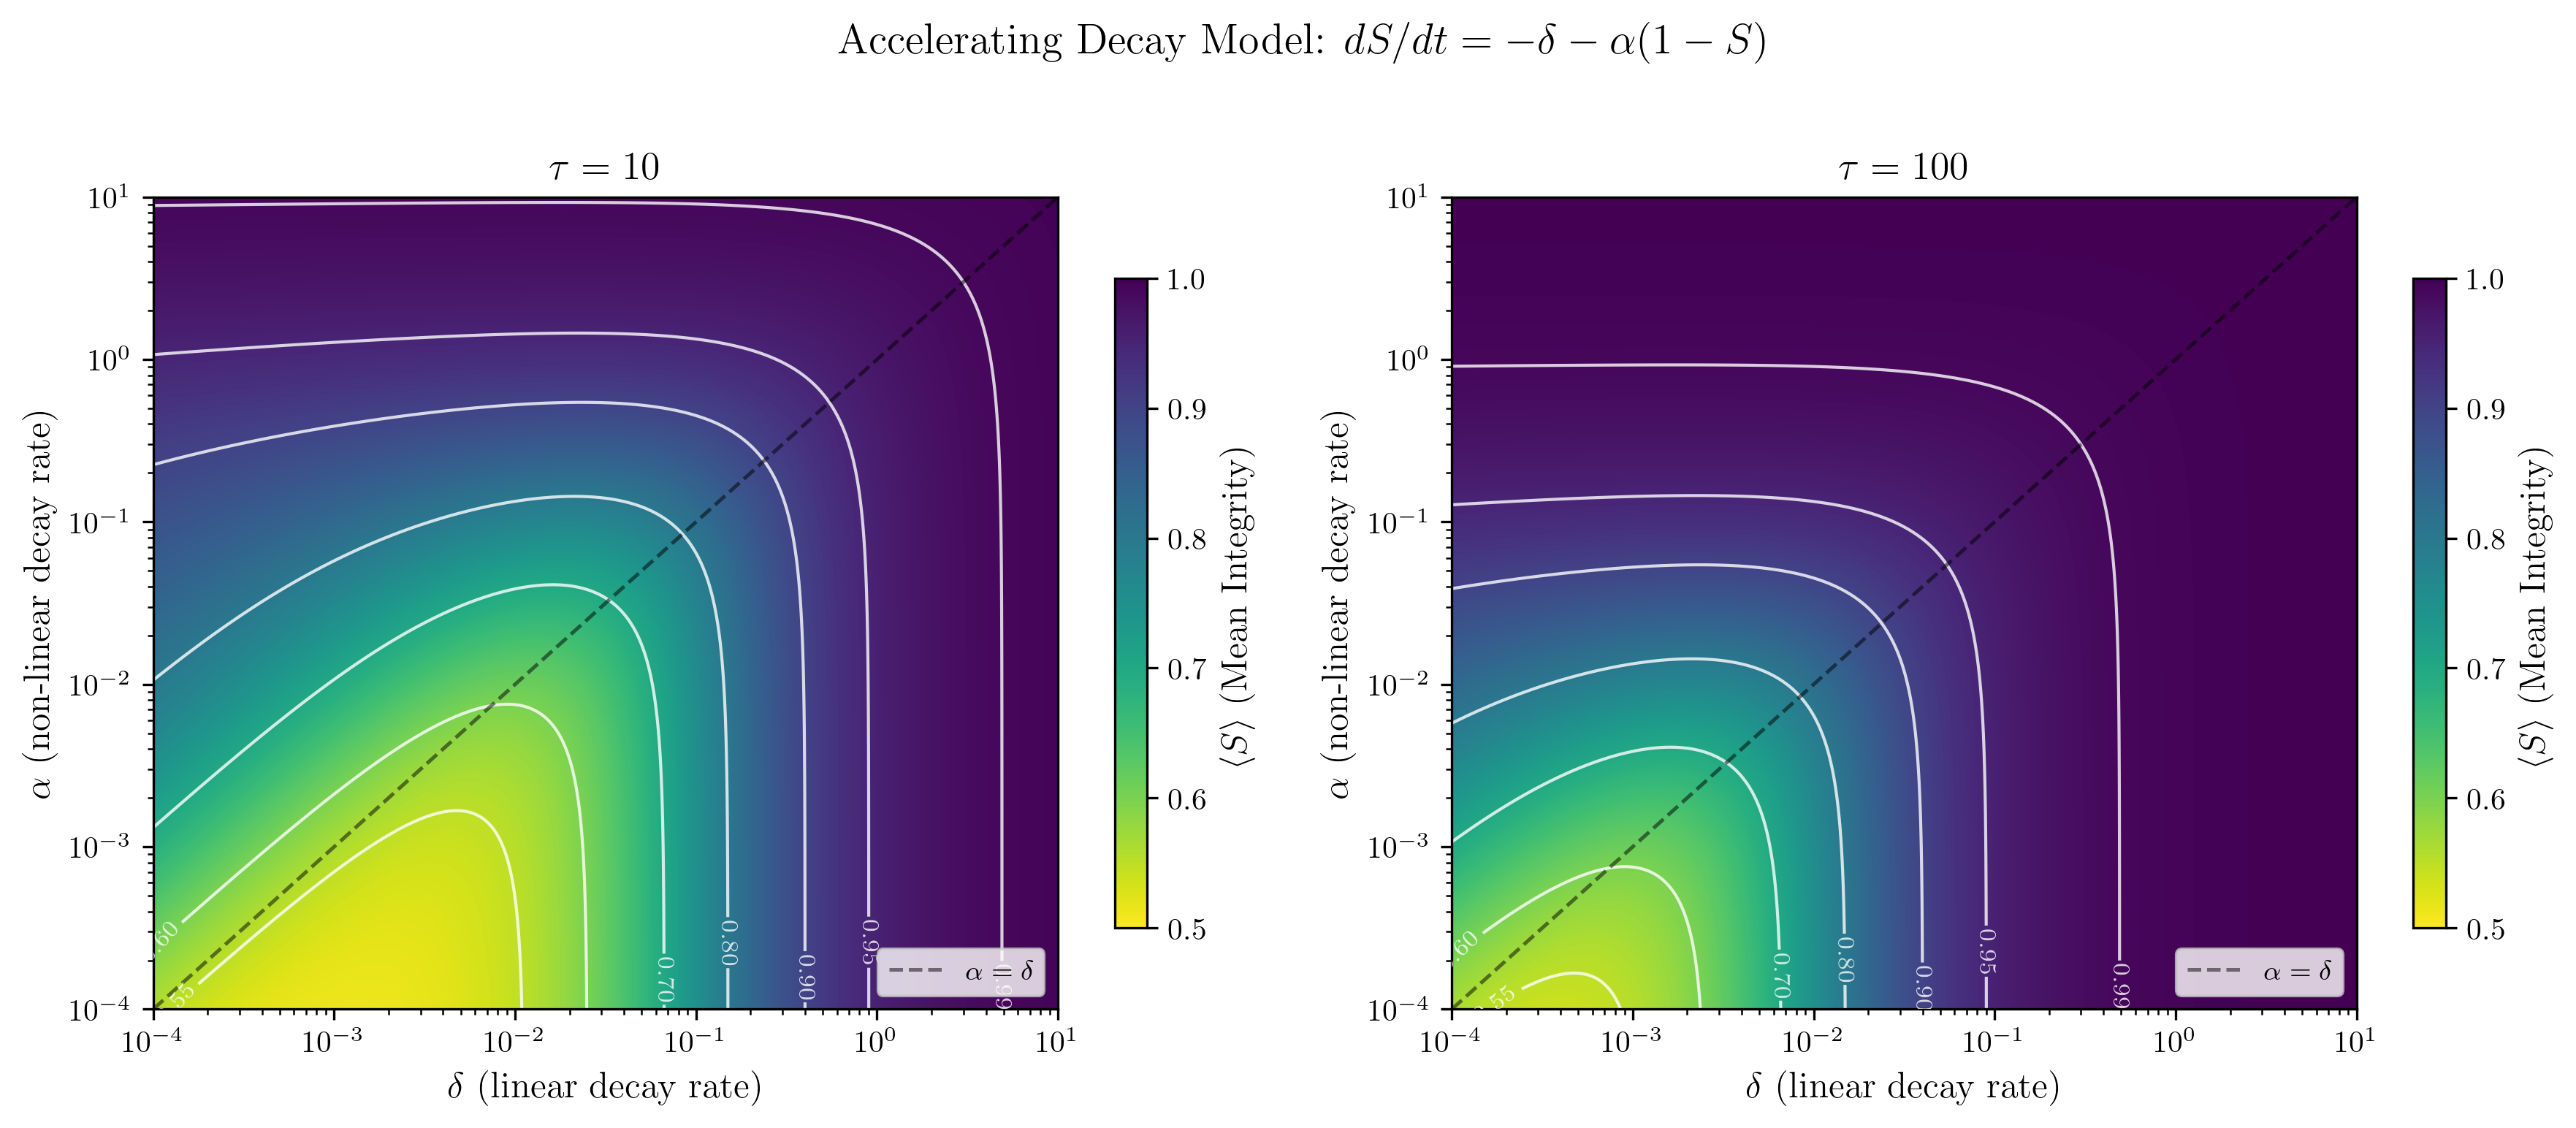

In [14]:
import numpy as np
import matplotlib.pyplot as plt


def  accelerate_snapshot_preservation(tau, delta, alpha):
    """
    Accelerate mixed model: dS/dt = -delta - alpha*(1-S)
    Decay starts slow at S=1 and accelerates toward S=0.
    """
    tau = np.asarray(tau, dtype=float)
    delta = np.asarray(delta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
    
    tau, delta, alpha = np.broadcast_arrays(tau, delta, alpha)
    S = np.empty_like(tau, dtype=float)
    
    # alpha == 0: recover linear model
    mask_linear = (alpha == 0)
    if np.any(mask_linear):
        S[mask_linear] = (2.0 * tau[mask_linear] * delta[mask_linear] + 1.0) \
                         / (2.0 * tau[mask_linear] * delta[mask_linear] + 2.0)
    
    # alpha > 0: reversed mixed model
    mask_mixed = ~mask_linear
    if not np.any(mask_mixed):
        return S
    
    t = tau[mask_mixed]
    d = delta[mask_mixed]
    a = alpha[mask_mixed]
    
    x = a / d
    L = np.log1p(x)
    
    # bracket = (1 + delta/alpha) * ln(1+alpha/delta) - 1
    small_x = x < 1e-8
    large_x = ~small_x
    bracket = np.empty_like(x)
    
    if np.any(large_x):
        xl = x[large_x]
        bracket[large_x] = (1.0 + 1.0 / xl) * np.log1p(xl) - 1.0
    
    if np.any(small_x):
        xs = x[small_x]
        bracket[small_x] = xs * (0.5 - xs * (1.0/6.0 - xs * (1.0/12.0 - xs * 0.05)))
    
    num = 1.0 + (1.0 / (a * t)) * bracket
    den = 1.0 + (1.0 / (a * t)) * L
    S[mask_mixed] = num / den
    
    return S


# --- Parameter ranges ---
delta = np.logspace(-4, 1, num=2000)
alpha = np.logspace(-4, 1, num=2000)
tau_values = [10, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    DELTA, ALPHA = np.meshgrid(delta, alpha, indexing='xy')
    S_rev = accelerate_snapshot_preservation(tau, DELTA, ALPHA)
    
    delta_edges = np.logspace(-4, 1, num=2001)
    alpha_edges = np.logspace(-4, 1, num=2001)
    
    im = ax.pcolormesh(delta_edges, alpha_edges, S_rev, 
                       shading='auto', cmap='viridis_r', vmin=0.5, vmax=1.0)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\delta$ (linear decay rate)', fontsize=12)
    ax.set_ylabel(r'$\alpha$ (non-linear decay rate)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    
    contour_levels = [0.55, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
    contours = ax.contour(DELTA, ALPHA, S_rev, levels=contour_levels,
                          colors='white', linewidths=1.0, alpha=0.8)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f', colors='white')
    
    ax.plot(delta, delta, 'k--', linewidth=1.2, alpha=0.5, label=r'$\alpha = \delta$')
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle(r'Accelerating Decay Model: $dS/dt = -\delta - \alpha(1-S)$', 
             fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('reversed_model_quicktest_heatmap.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_accelerating_decay_heatmap.png", bbox_inches='tight', dpi=300)
plt.show()

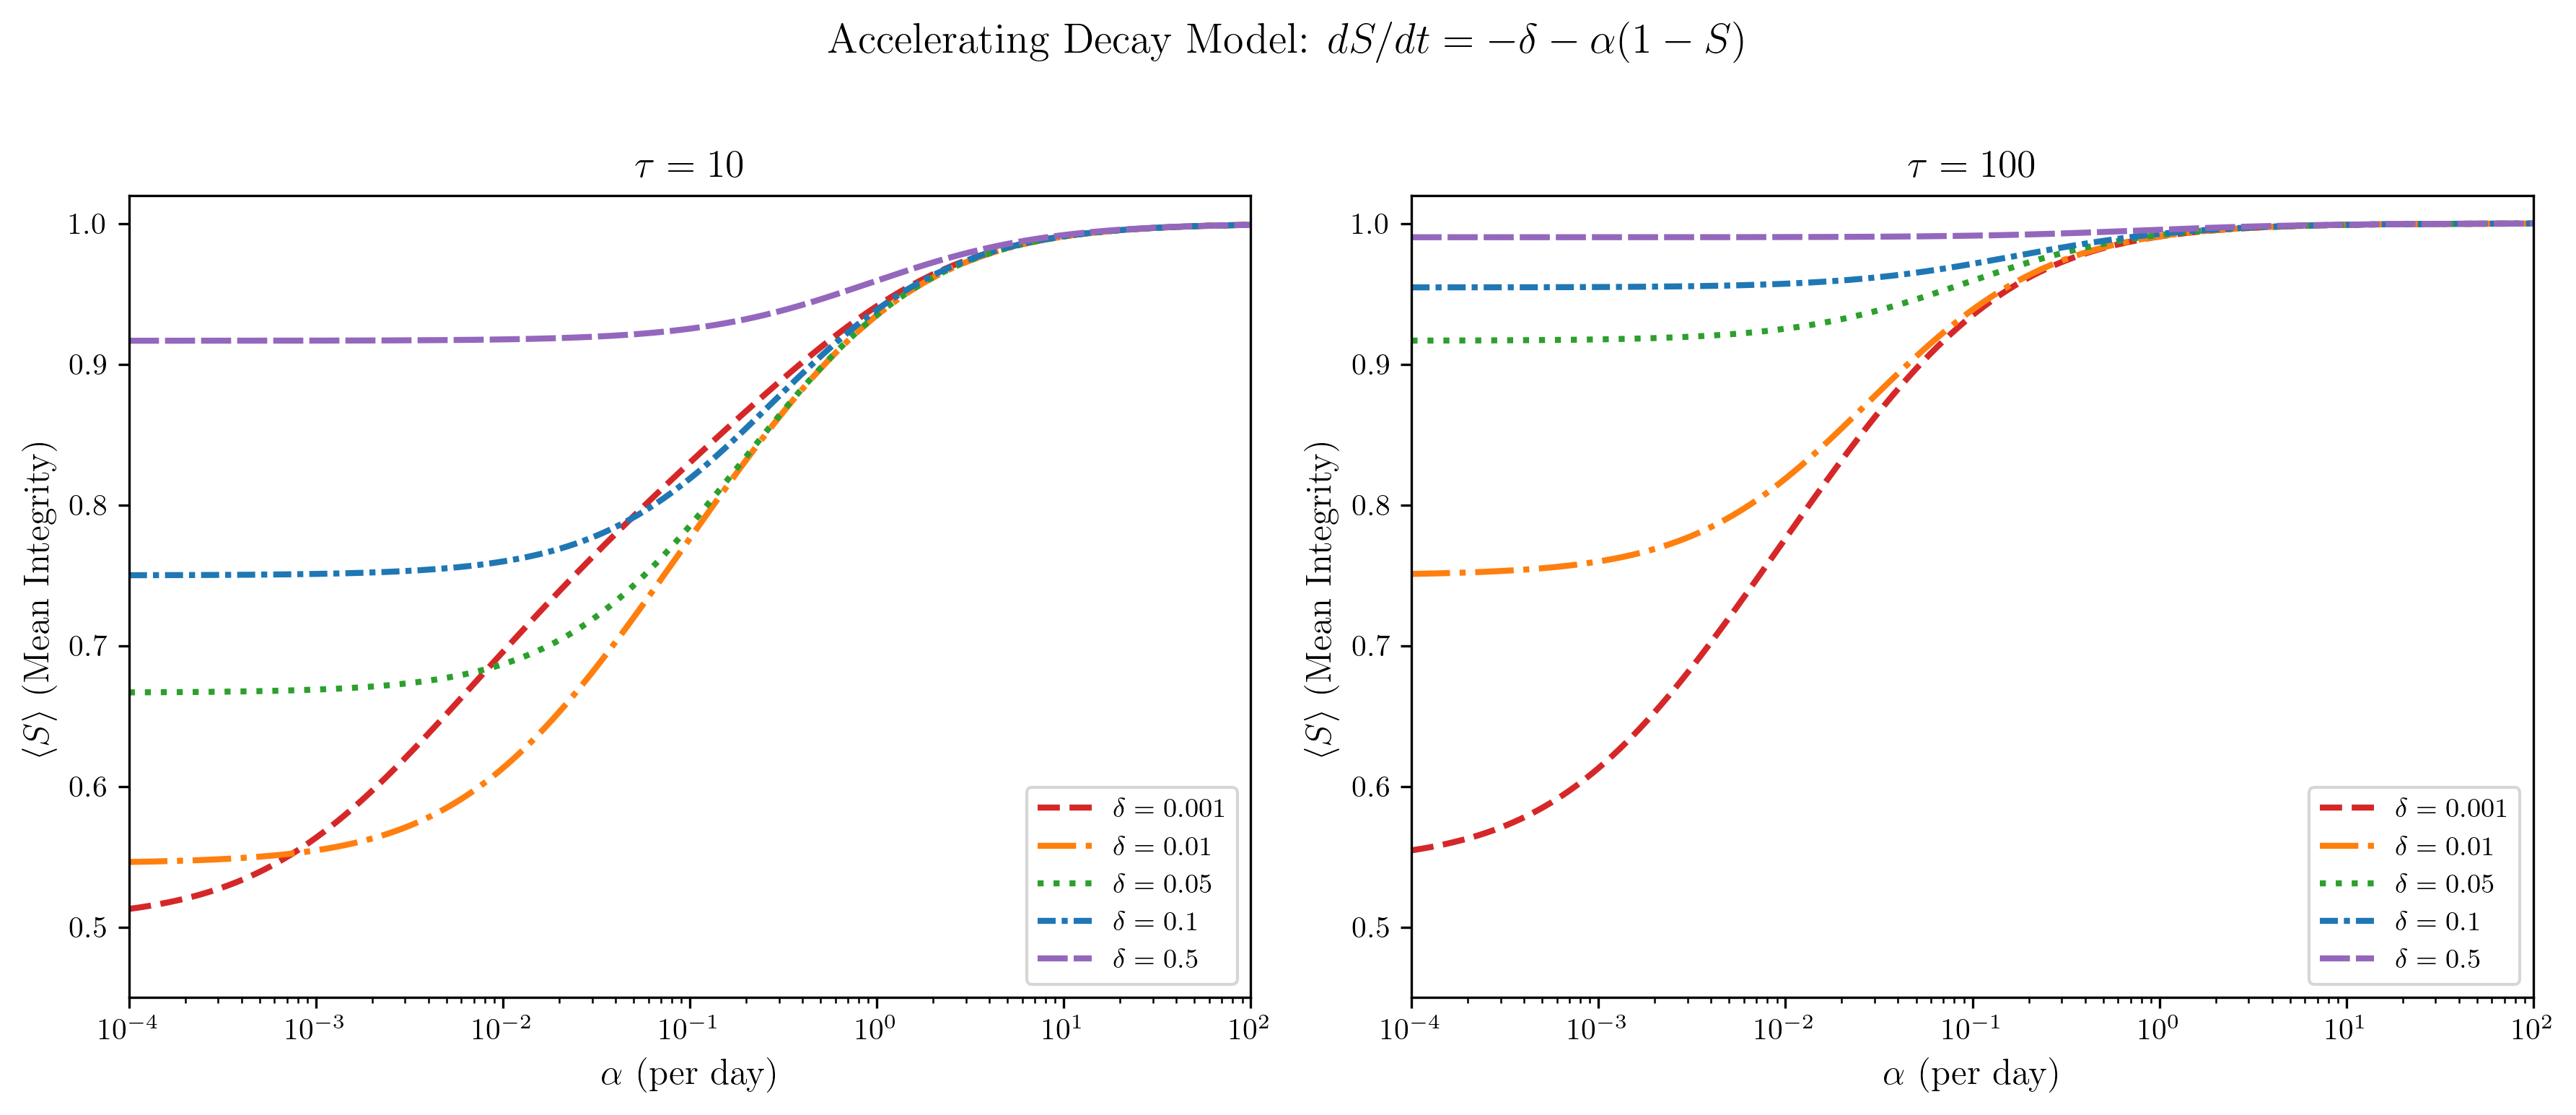

In [15]:
import numpy as np
import matplotlib.pyplot as plt





# --- Plot settings ---
tau_values = [10, 100]
deltas = [0.001, 0.01, 0.05, 0.1, 0.5]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
alpha_vals = np.logspace(-4, 2, 2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    for delta, color, ls in zip(deltas, colors, linestyles):
        S = accelerate_snapshot_preservation(tau, delta, alpha_vals)
        ax.plot(alpha_vals, S, color=color, linewidth=2, label=rf'$\delta = {delta}$', ls = ls)
        

    
    # Reference lines
    #ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, 
    #           label=r'$\langle S \rangle = 0.5$')
    #ax.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_xlabel(r'$\alpha$ (per day)', fontsize=12)
    ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    ax.set_ylim(0.45, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    #ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(alpha_vals.min(), alpha_vals.max())
plt.suptitle(r'Accelerating Decay Model: $dS/dt = -\delta - \alpha(1-S)$', 
             fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('example_Non_linear_decay_model_lines.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_accelerating_decay_alpha.png", bbox_inches='tight', dpi=300)
plt.show()

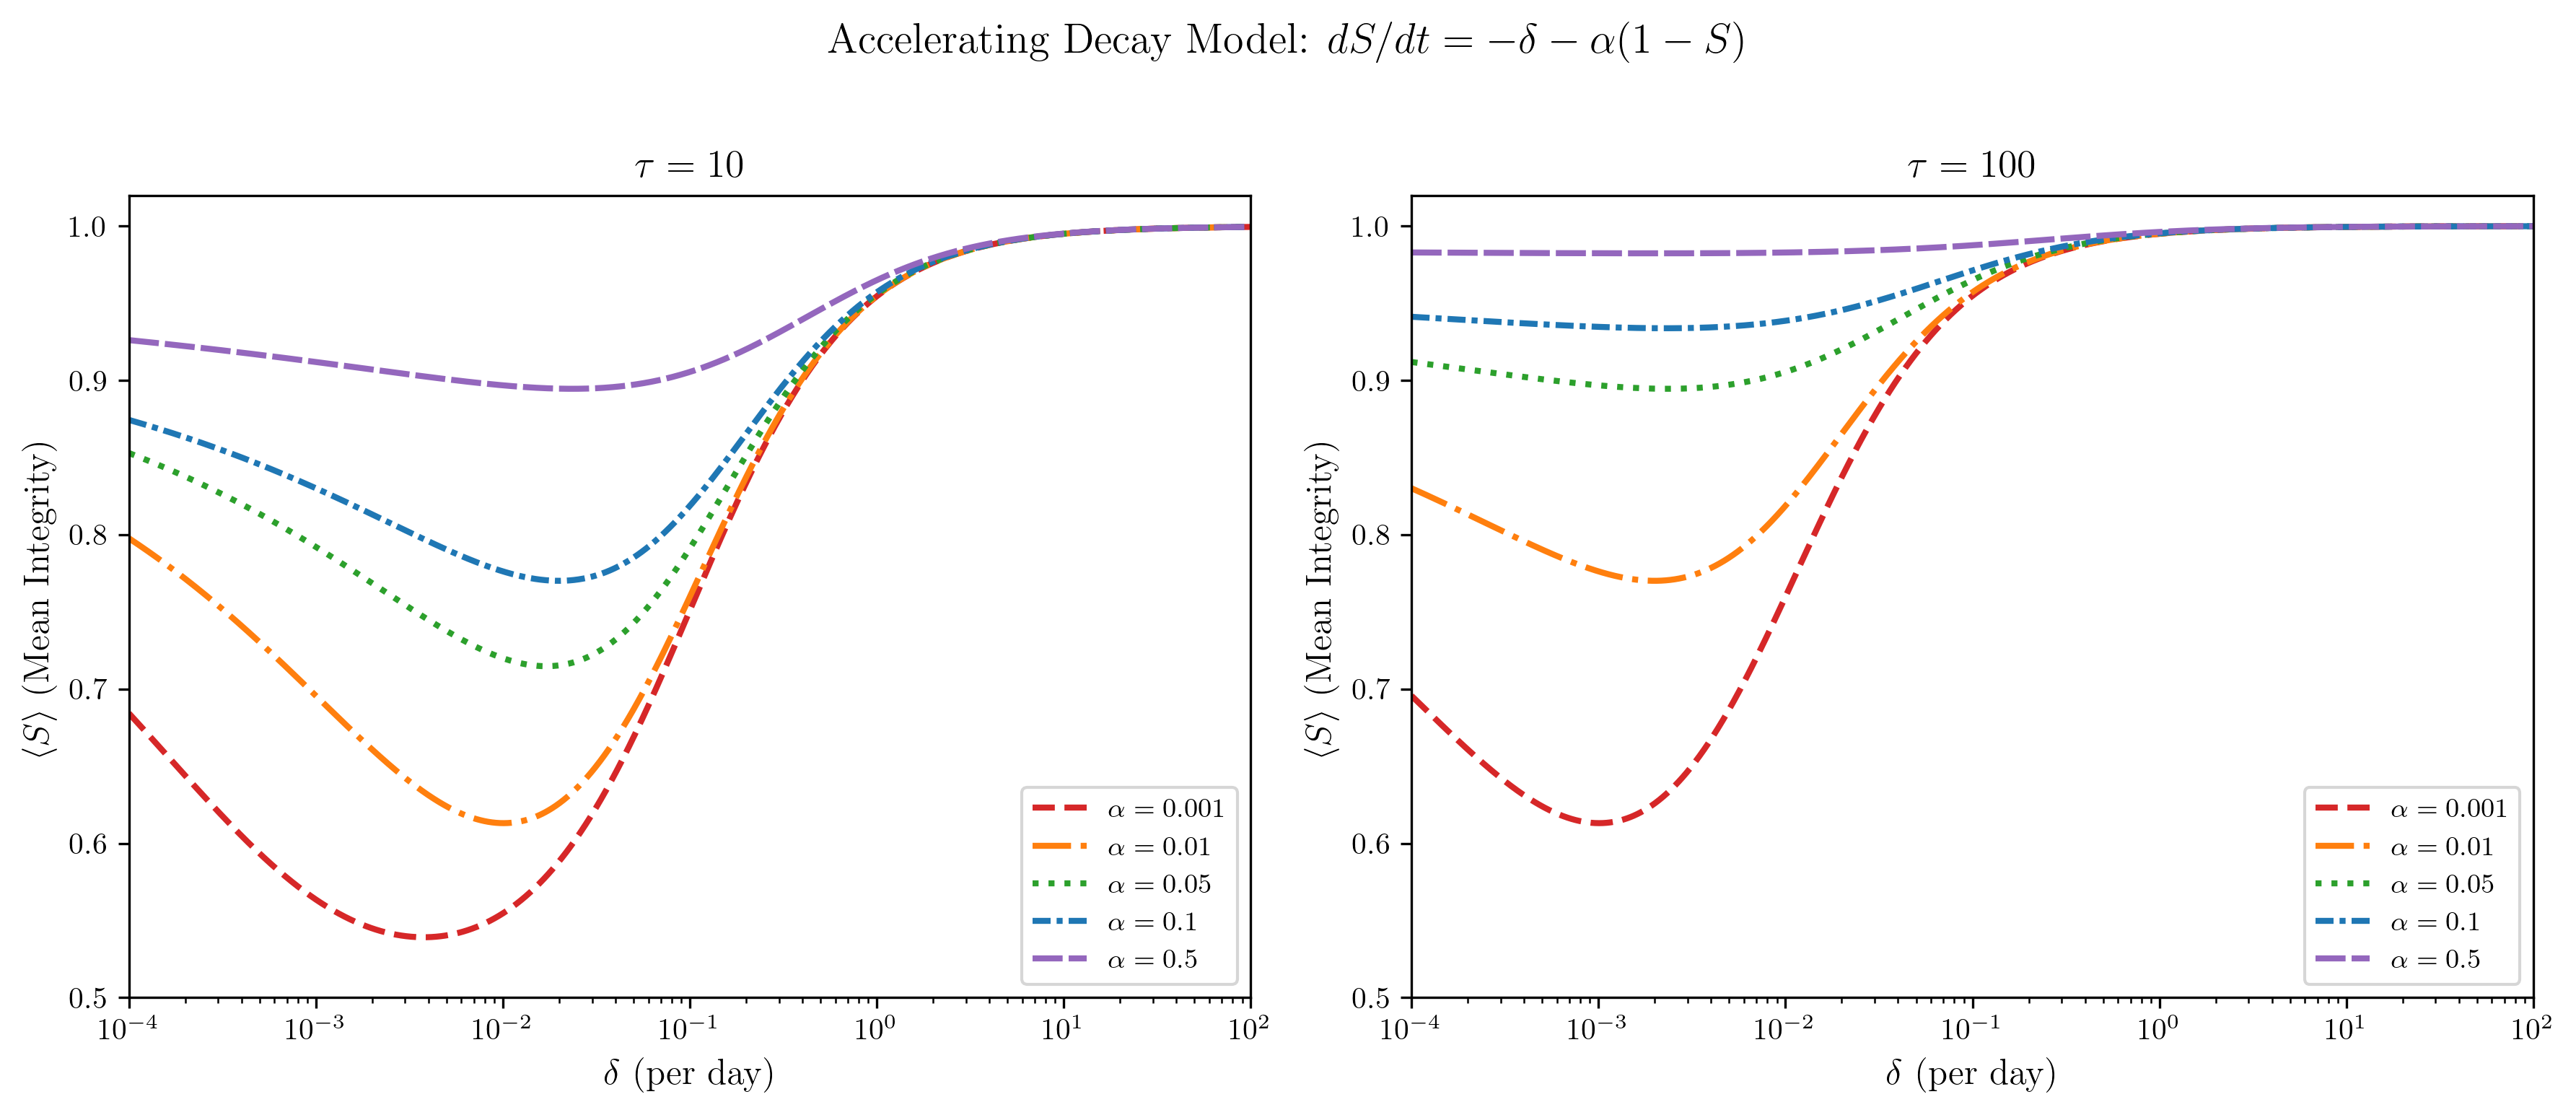

In [16]:
# --- Plot settings ---
tau_values = [10, 100]
alphas = [0.001, 0.01, 0.05, 0.1, 0.5]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']
linestyles = ['--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]
deltas_vals = np.logspace(-4, 2, 2000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tau in zip(axes, tau_values):
    for alpha, color, ls in zip(alphas, colors, linestyles):
        S = accelerate_snapshot_preservation(tau, deltas_vals, alpha)
        ax.plot(deltas_vals, S, color=color, linewidth=2, label=rf'$\alpha = {alpha}$', ls =ls)
        

    
    # Reference lines
    #ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, 
    #           label=r'$\langle S \rangle = 0.5$')
    #ax.axhline(1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    ax.set_xscale('log')
    ax.set_xlabel(r'$\delta$ (per day)', fontsize=12)
    ax.set_ylabel(r'$ \langle S \rangle $ (Mean Integrity)', fontsize=12)
    ax.set_title(rf'$\tau = {tau}$', fontsize=13)
    ax.set_ylim(0.5, 1.02)
    ax.legend(loc='lower right', fontsize=9)
    #ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(deltas_vals.min(), deltas_vals.max())
plt.suptitle(r'Accelerating Decay Model: $dS/dt = -\delta - \alpha(1-S)$', 
             fontsize=14, y=1.02)
plt.tight_layout()
#plt.savefig('example_Non_linear_decay_model_lines.png', dpi=300, bbox_inches='tight')
#plt.savefig("paper_figure_draft_accelerating_decay_delta.png", bbox_inches='tight', dpi=300)
plt.show()